In [1]:
!pip install mlxtend

## 1. Preparación de datos

In [2]:
import pandas as pd

# 1. Configuración de visualización
pd.set_option('display.max_columns', None)  
pd.set_option('display.max_rows', 100)

data = pd.read_pickle("../data/telecom_churn_clean.pkl")

data.info()
data.head()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   Churn                                  7043 non-null   int64  
 4   Partner_Yes                            7043 non-null   int64  
 5   Dependents_Yes                         7043 non-null   int64  
 6   MultipleLines_Yes                      7043 non-null   int64  
 7   InternetService_Fiber optic            7043 non-null   int64  
 8   InternetService_No                     7043 non-null   int64  
 9   OnlineSecurity_Yes                     7043 non-null   int64  
 10  OnlineBackup_Yes                       7043 non-null   int64  
 11  DeviceProtectio

,SeniorCitizen,tenure,MonthlyCharges,Churn,Partner_Yes,Dependents_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1
2,0,2,53.85,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,0,0,0,0,0,0,1,0,1,1,0,0,1,0,0,0,0,0
4,0,2,70.70,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0


Vamos a proceder a separar nuestro conjunto de datos en 2 dataframes, uno con la variable objetivo únicamente (y) y otro con todas las variables predictoras (X). Dividimos a conitnuación, cada uno de estos 2 conjuntos en 2 conjuntos a su vez: Uno de entrenamiento y otro para validación o test.

In [3]:
# Separar variables predictoras y objetivo
X = data.drop(columns='Churn')
y = data['Churn']

## 2. Modelo Base de Regresión Logística

### 2.1. Ajuste del Modelo con el Conjunto Completo de Variables

In [4]:
from sklearn.model_selection import train_test_split

# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Una vez concluida la preparación de los datos, nos adentramos de lleno en la fase de modelado predictivo utilizando un algoritmo de Regresión Logística. Este modelo es el idóneo para nuestro problema de clasificación binaria, ya que nos permite estimar la probabilidad de que ocurra el suceso de abandono basándonos en una función sigmoide acotada estrictamente entre 0 y 1. 

In [5]:
!pip install --upgrade statsmodels

In [6]:
import statsmodels.api as sm

# Añadir una constante para el término independiente 
X_train_const = sm.add_constant(X_train)

# Crear y ajustar el modelo
logit_model = sm.Logit(y_train, X_train_const)
result = logit_model.fit(maxiter=100)

# Resumen completo
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.413603
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 5634
Model:                          Logit   Df Residuals:                     5613
Method:                           MLE   Df Model:                           20
Date:                Sun, 28 Jun 2026   Pseudo R-squ.:                  0.2851
Time:                        19:01:23   Log-Likelihood:                -2330.2
converged:                       True   LL-Null:                       -3259.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                     0.3246      

**Conclusiones**:

Notas Generales:

- Pseudo R-squ. (0.2851): valores entre 0.2 y 0.4 indican un buen ajuste del modelo. Se puede decir que es capaz de explicar un 28.5% más sobre la variable objetivo que el modelo nulo.
- LLR p-value (0.000): al ser menor al 5% es un buen modelo.

Examne de las Variables:
1. El peligro de la Fibra Óptica (InternetService_Fiber optic = +1.5648): Es el coeficiente positivo más alto. Tener fibra óptica multiplica drásticamente la probabilidad de que el cliente abandone la empresa. ¡Aquí hay un problema grave de negocio (quizás el servicio es caro o falla mucho)!

2. El poder de los contratos (Contract_Two year = -1.3616): Es un coeficiente negativo fortísimo. Los clientes con contratos de dos años tienen una probabilidad bajísima de irse; el contrato los retiene con éxito.

3. La fidelidad del tiempo (tenure = -0.0328): Por cada mes extra que un cliente pasa en la compañía (tenure), el riesgo de que se vaya disminuye de forma constante.

4. El método de pago conflictivo (PaymentMethod_Electronic check = +0.3835): Los clientes que pagan con cheque electrónico tienen una tendencia significativamente mayor a abandonar la empresa en comparación con los otros métodos.

Vamos a pasar a calcular los odds de los coeficientes para interpretarlos.

In [7]:
import numpy as np

# Obtener los coeficientes
coefficients = result.params

# Calcular los odds ratios aplicando exp a los coeficientes
odds_ratios = np.exp(coefficients)

# Crear un DataFrame con las dos columnas: coeficientes y odds ratios
tab_coefs_odds = pd.DataFrame({
    'Coeficientes': coefficients,
    'Odds Ratios': odds_ratios
})

# Mostrar la tabla
tab_coefs_odds.sort_values(by='Coeficientes',ascending=False)

,Coeficientes,Odds Ratios
InternetService_Fiber optic,1.564842,4.781922
StreamingTV_Yes,0.534058,1.705840
StreamingMovies_Yes,0.533336,1.704610
MultipleLines_Yes,0.458435,1.581596
PaymentMethod_Electronic check,0.383474,1.467373
PaperlessBilling_Yes,0.366793,1.443099
const,0.324560,1.383421
SeniorCitizen,0.142137,1.152735
DeviceProtection_Yes,0.126132,1.134431
PaymentMethod_Mailed check,0.111618,1.118086


Al analizar los odds, podemos interpretar por ejemplo que variables como **InternetService_Fiber optic** hacen que cuando el registro es de esta categoría, los odds respecto de cuando no tiene esta condición, aumentan en un factor 4.78. Esto hace que la **probabilidad de que el cliente abandone la compañía (Churn) sea mayor**. Es decir, que el hecho de que el usuario tenga contratada fibra óptica esté más relacionado con el hecho de que el cliente se dé de baja más que de que permanezca en la empresa.

en el otro extremo de la tabla tenemos **Contract_Two year**cuyos odds decaen al 26% de su valor, indicando que a mayor duración del contrato, más probable es que el cliente permanezca en la compañía.

Vamos ahora a analizar los valores predichos en el conjunto de entrenamiento para ver qué tal clasifica nuestro modelo según otras métricas.

### 2.2. Evaluación Inicial y Análisis del Umbral Estándar (0.5), Umbral (0.2)

In [8]:
from sklearn.metrics import confusion_matrix

# Hacer predicciones (probabilidad de clase 1)
y_proba = result.predict(X_train_const)

# Convertir las probabilidades en predicciones binarias
threshold = 0.5
y_pred = (y_proba >= threshold).astype(int)

# Construir la matriz de confusión
cm = confusion_matrix(y_train, y_pred)

# Evaluación del modelo
print("Matriz de confusión:")
print(cm)

# Convertir la matriz de confusión a porcentajes
cm_percentage = cm.astype('float') / cm.sum() * 100

# Imprimir la matriz en porcentajes con formato legible
print("Matriz de confusión en porcentajes:")
print(np.round(cm_percentage, 2))

Matriz de confusión:
[[3720  419]
 [ 683  812]]
Matriz de confusión en porcentajes:
[[66.03  7.44]
 [12.12 14.41]]


 En los resultados se muestra tanto en valor absoluto el número de registros como en porcentajes. Si vemos los porcentajes, vemos que el volumen de **falsos negativos es de un 12.12%**, tenemos un volumen muy elevado de este tipo de errores. Del mismo modo, los **falsos positivos suponen un 7.44%** que tampoco es desdeñable. En conclusión, no parece que nuestro modelo esté captando bien la variabilidad de la variable objetivo. Parece que tiene un problema de sesgo importante.  Seguimos analizando métricas del conjunto entrenado. Vamos a calcular los ratios a partir de la matriz de confusión.

In [9]:
from sklearn.metrics import classification_report

# Imprimir el reporte de clasificación con las métricas detalladas
print("Reporte de clasificación:")
print(classification_report(y_train, y_pred))

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      4139
           1       0.66      0.54      0.60      1495

    accuracy                           0.80      5634
   macro avg       0.75      0.72      0.73      5634
weighted avg       0.80      0.80      0.80      5634



La exactitud global (accuracy) se sitúa en un 80%, lo que indica que el modelo acierta en 8 de cada 10 clasificaciones. A pesar de ser un porcentaje aparentemente elevado, esta métrica se encuentra inflada por la clase mayoritaria (0 - Clientes que se quedan), la cual presenta una precisión del 84% y una sensibilidad del 90%.

El verdadero desafío del negocio se encuentra en la clase positiva (1 - Churn):
- Precisión (66%): Significa que de cada 100 alertas de fuga que genera el modelo, 66 son correctas, teniendo un 34% de falsas alarmas (falsos positivos).
- Sensibilidad o Recall (54%): Este es el punto más crítico. El modelo solo es capaz de identificar y "capturar" al 54% de los clientes que realmente se van a dar de baja. Esto implica que un 46% de los clientes en riesgo de fuga se le escapan por completo al modelo (falsos negativos), confirmando el diagnóstico previo de la matriz de confusión.
  
Como consecuencia de este desequilibrio, el F1-score de la clase positiva queda penalizado en un 60%.

Vamos a visualizar ahora la curva ROC y el area bajo ella. Recordemos que seguimos con el conjunto de entrenamiento.


AUC-ROC: 0.848


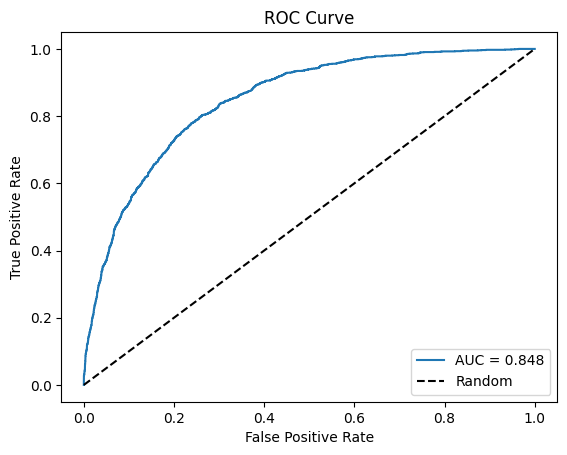

In [10]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Métrica AUC-ROC
auc = roc_auc_score(y_train, y_proba)
print(f"\nAUC-ROC: {auc:.3f}")

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_train, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

Por la pinta que tiene la curva, claramente el modelo que hemos creado clasifica mejor que un modelo aleatorio. El area bajo la curva de este modelo, 0.848, es bastante mejor que el 0.5 del modelo aleatorio y de hecho es una puntuación magnífica. Es un modelo muy bueno o sobresaliente.

Vamos a mostrar en un gráfico de densidad las probabilidades predichas por el modelo en el conjunto de entrenamiento.

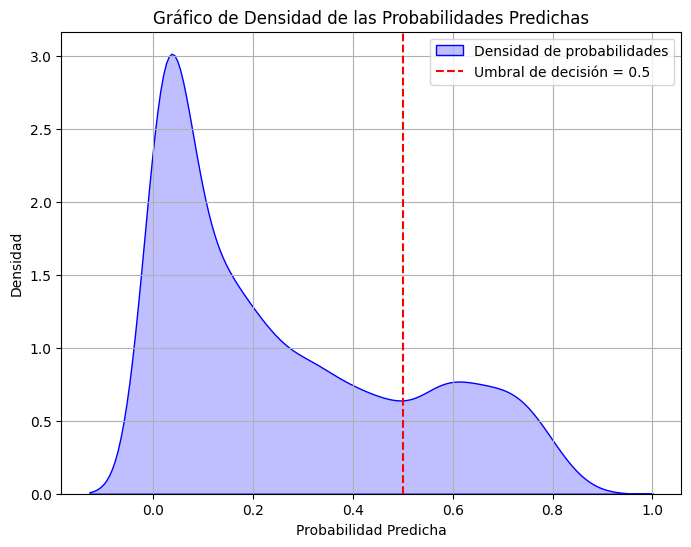

In [11]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.kdeplot(y_proba, fill=True, color="blue", label="Densidad de probabilidades")
plt.title('Gráfico de Densidad de las Probabilidades Predichas')
plt.xlabel('Probabilidad Predicha')
plt.ylabel('Densidad')
plt.axvline(x=0.5, color='red', linestyle='--', label="Umbral de decisión = 0.5")
plt.legend()
plt.grid(True)
plt.show()

A la vista del gráfico de densidad, observamos que la gran masa de probabilidades se concentra fuertemente en la zona baja (en torno al 0.05), lo que demuestra que el modelo identifica con mucha contundencia a los clientes que tienen una fidelidad clara. Sin embargo, al mantener el umbral de decisión en el 0.5 por defecto, la línea de corte resulta demasiado estricta y provoca que pasemos por alto a la mayoría de los clientes que muestran indicios moderados de querer marcharse.

Desde la perspectiva estratégica de la empresa de telecomunicaciones, el coste de perder a un cliente para siempre (Falso Negativo) es muchísimo más alto que el coste de ofrecerle una promoción de retención a un cliente que en realidad pensaba quedarse (Falso Positivo). En definitiva, preferimos que no se nos escape nadie. Aunque bajar el umbral empeorará la precisión de la clase 0 (cometeremos más errores con los que se quedan, confundiéndolos con bajas), lograremos el verdadero objetivo comercial: maximizar la captura de los clientes de la clase 1 (Churn).

Por lo tanto, el siguiente paso es modificar el umbral de decisión situándolo en 0.2 para volver al modelo más sensible frente al riesgo de fuga. Vamos a recalcular la matriz de confusión y el reporte de clasificación bajo este nuevo parámetro para evaluar la mejora en la sensibilidad (Recall).

In [12]:
from sklearn.metrics import confusion_matrix, classification_report

# Hacer predicciones (probabilidad de clase 1)
y_proba = result.predict(X_train_const)

# Convertir las probabilidades en predicciones binarias
threshold = 0.2
y_pred = (y_proba >= threshold).astype(int)

# Construir la matriz de confusión
cm = confusion_matrix(y_train, y_pred)

# Evaluación del modelo
print("Matriz de confusión:")
print(cm)

# Convertir la matriz de confusión a porcentajes
cm_percentage = cm.astype('float') / cm.sum() * 100

# Imprimir la matriz en porcentajes con formato legible
print("Matriz de confusión en porcentajes:")
print(np.round(cm_percentage, 2))

Matriz de confusión:
[[2727 1412]
 [ 213 1282]]
Matriz de confusión en porcentajes:
[[48.4  25.06]
 [ 3.78 22.75]]


Si vemos los porcentajes, vemos que el volumen de falsos negativos se ha reducido drásticamente a un 3.78% (frente al 12.12% que teníamos con el umbral estándar), lo que confirma que hemos logrado blindar casi por completo la fuga inadvertida de clientes. Por otro lado, y tal como habíamos anticipado, los falsos positivos se han elevado hasta un 25.06%; esto representa un volumen considerable de falsas alarmas, pero resulta completamente aceptable al priorizar la retención.

In [13]:
print("\nReporte de clasificación:")
print(classification_report(y_train, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.93      0.66      0.77      4139
           1       0.48      0.86      0.61      1495

    accuracy                           0.71      5634
   macro avg       0.70      0.76      0.69      5634
weighted avg       0.81      0.71      0.73      5634



A la vista del reporte de clasificación, si lo comparamos con el modelo anterior (umbral 0.5), podemos concluir que este modelo es notablemente mejor para nuestro objetivo de negocio, a pesar de que la exactitud global (accuracy) haya disminuido del 80% al 71%.

El éxito rotundo del cambio se observa en la clase 1 (Churn): la sensibilidad o recall ha subido de un insuficiente 54% a un excelente 86%. Esto significa que ahora el modelo es capaz de capturar a la gran mayoría de los clientes en riesgo de fuga, reduciendo drásticamente los casos que se nos escapan de forma inadvertida.


AUC-ROC: 0.848


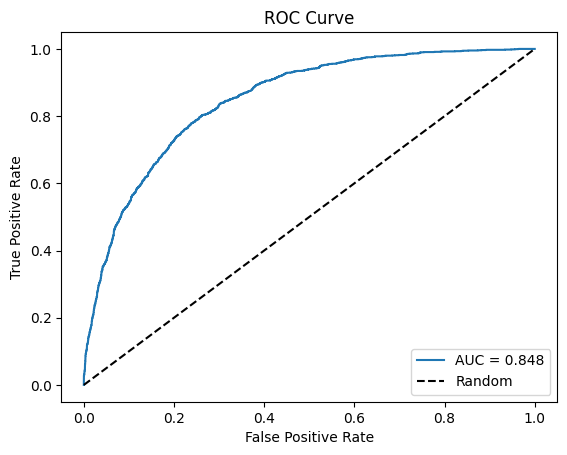

In [14]:
# Métrica AUC-ROC
auc = roc_auc_score(y_train, y_proba)
print(f"\nAUC-ROC: {auc:.3f}")

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_train, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

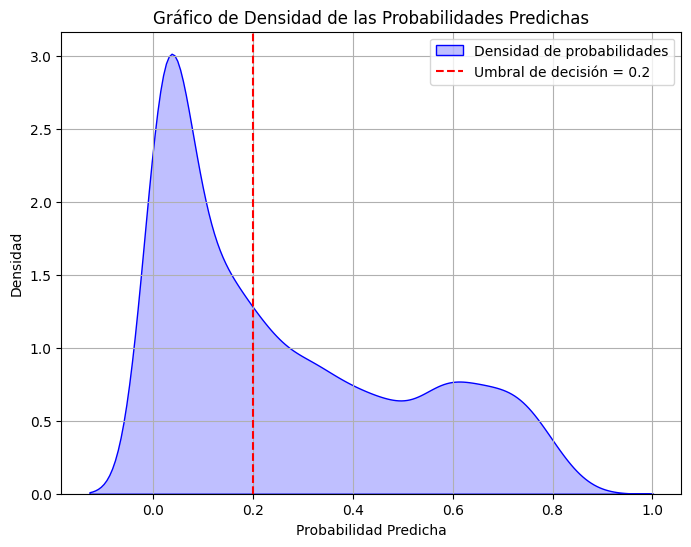

In [15]:
plt.figure(figsize=(8, 6))
sns.kdeplot(y_proba, fill=True, color="blue", label="Densidad de probabilidades")
plt.title('Gráfico de Densidad de las Probabilidades Predichas')
plt.xlabel('Probabilidad Predicha')
plt.ylabel('Densidad')
plt.axvline(x=0.2, color='red', linestyle='--', label="Umbral de decisión = 0.2")
plt.legend()
plt.grid(True)
plt.show()

Ahora vamos a comparar los resultados de las métricas del primer modelo en el conjunto de entrenamiento con las del conjunto de validación para ver que tal generaliza con datos que nunca ha visto.

In [16]:
# Añadir una constante para el término independiente
X_test_const = sm.add_constant(X_test)

# Hacer predicciones (probabilidad de clase 1)
y_proba = result.predict(X_test_const)

# Convertir las probabilidades en predicciones binarias
threshold = 0.5
y_pred = (y_proba >= threshold).astype(int)

# Construir la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Evaluación del modelo
print("Matriz de confusión:")
print(cm)

# Convertir la matriz de confusión a porcentajes
cm_percentage = cm.astype('float') / cm.sum() * 100

# Imprimir la matriz en porcentajes con formato legible
print("Matriz de confusión en porcentajes:")
print(np.round(cm_percentage, 2))

Matriz de confusión:
[[919 116]
 [167 207]]
Matriz de confusión en porcentajes:
[[65.22  8.23]
 [11.85 14.69]]


In [17]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409




AUC-ROC: 0.839


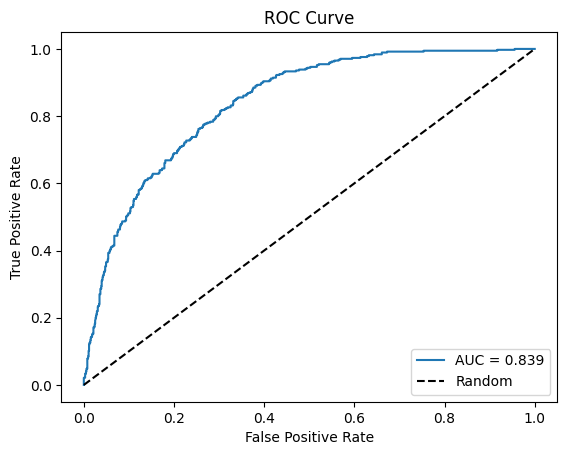

In [18]:
# Métrica AUC-ROC
auc = roc_auc_score(y_test, y_proba)
print(f"\nAUC-ROC: {auc:.3f}")

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

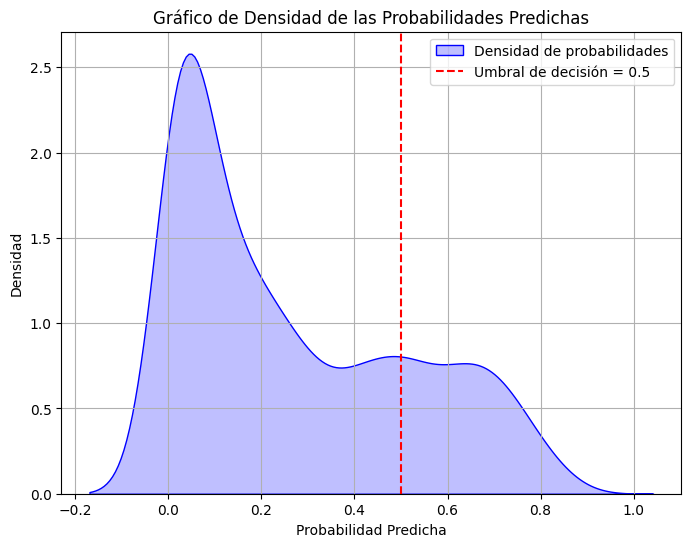

In [19]:
plt.figure(figsize=(8, 6))
sns.kdeplot(y_proba, fill=True, color="blue", label="Densidad de probabilidades")
plt.title('Gráfico de Densidad de las Probabilidades Predichas')
plt.xlabel('Probabilidad Predicha')
plt.ylabel('Densidad')
plt.axvline(x=0.5, color='red', linestyle='--', label="Umbral de decisión = 0.5")
plt.legend()
plt.grid(True)
plt.show()

Si analizamos la matriz de confusión y el reporte de clasificación en Test, observamos que la exactitud global se mantiene congelada en un 80%, exactamente igual que en el entrenamiento. El indicador global de discriminación AUC-ROC apenas sufre una caída insignificante, pasando de 0.848 a 0.839. En el ámbito del Machine Learning, una pérdida de rendimiento menor al 1% al pasar de Train a Test es el escenario ideal, confirmando de manera rotunda que nuestro modelo no sufre ningún problema de sobreajuste (overfitting) y que los coeficientes calculados son estables y fiables para el negocio.

A nivel de errores, la distribución porcentual se replica casi a la perfección: los falsos negativos se sitúan en un 11.85% (frente al 12.12% en Train) y los falsos positivos en un 8.23% (frente al 7.44% en Train). El gráfico de densidad adjunto corrobora esta estabilidad visualmente, manteniendo la misma silueta bimodal con la gran concentración de clientes estables a la izquierda del umbral 0.5.

Ahora cambiamos el valor del umbral situandolo en 0.2:

In [20]:
# Añadir una constante para el término independiente
X_test_const = sm.add_constant(X_test)

# Hacer predicciones (probabilidad de clase 1)
y_proba = result.predict(X_test_const)

# Convertir las probabilidades en predicciones binarias
threshold = 0.2
y_pred = (y_proba >= threshold).astype(int)

# Construir la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Evaluación del modelo
print("Matriz de confusión:")
print(cm)

# Convertir la matriz de confusión a porcentajes
cm_percentage = cm.astype('float') / cm.sum() * 100

# Imprimir la matriz en porcentajes con formato legible
print("Matriz de confusión en porcentajes:")
print(np.round(cm_percentage, 2))

Matriz de confusión:
[[680 355]
 [ 54 320]]
Matriz de confusión en porcentajes:
[[48.26 25.2 ]
 [ 3.83 22.71]]


In [21]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.93      0.66      0.77      1035
           1       0.47      0.86      0.61       374

    accuracy                           0.71      1409
   macro avg       0.70      0.76      0.69      1409
weighted avg       0.81      0.71      0.73      1409



Al analizar las métricas, confirmamos que el modelo replica con una exactitud asombrosa el rendimiento del entrenamiento, lo que demuestra su total robustez y nulo sobreajuste. La exactitud global (accuracy) se consolida en el 71% y el F1-score de la clase positiva se clava en el 61%.

El dato clave para la viabilidad del proyecto es que la sensibilidad o recall de la clase 1 se mantiene intacto en un excelente 86%. En términos reales, el modelo detectará con éxito a 320 de los 374 clientes que van a abandonar la compañía en este conjunto de datos nuevos, permitiendo que el departamento de marketing actúe a tiempo. Los clientes que sufren una fuga inadvertida (falsos negativos) suponen un residual 3.83%. El peaje de falsas alarmas (falsos positivos) se estabiliza en el 25.20%, una cifra completamente asumible dentro del presupuesto comercial asignado para la campaña de fidelización.

En conclusión, la modificación del umbral de decisión a 0.2 se valida como la solución óptima para el problema de negocio planteado, transformando un algoritmo inicialmente sesgado en una herramienta proactiva de retención altamente eficiente y perfectamente preparada para producción.

In [22]:
# Calcular el área hacia la derecha del umbral de 0.5
area_right = np.sum(y_proba > 0.5) / len(y_proba)
print(f"El área hacia la derecha del umbral 0.5 es: {area_right:.4f}")

# Calcular el área hacia la derecha del umbral de 0.2
area_right = np.sum(y_proba > 0.2) / len(y_proba)
print(f"El área hacia la derecha del umbral 0.2 es: {area_right:.4f}")

El área hacia la derecha del umbral 0.5 es: 0.2292
El área hacia la derecha del umbral 0.2 es: 0.4791


A la vista de los resultados numéricos, confirmamos el impacto directo que tiene la elección del umbral sobre la dimensión:

- Con el umbral estándar de 0.5, el área hacia la derecha es de 0.2292. Esto significa que el modelo solo calificaría en riesgo de fuga al 22.92% del total de los clientes. En el caso de hacer campaña sería muy reducida y económica para la empresa, pero comercialmente ineficaz, ya que dejaría sin detectar a casi la mitad de las bajas reales (alto volumen de falsos negativos).

- Con nuestro umbral optimizado de 0.2, el área hacia la derecha se duplica hasta 0.4791. Esto implica que pasamos a etiquetar en situación de riesgo al 47.91% de la cartera de clientes (casi la mitad de la muestra analizada).

En conclusión bajar el umbral a 0.2 duplica el volumen de alertas, exigirá acciones de fidelización para el 48% de los usuarios.

### 2.3.  Selección distinta de las variables predictoras para mejorar Modelo

Ahora vamos a intentar mejorar nuestro modelo de Regresión Logística y, para ello, realizaremos una selección distinta de las variables predictoras (Feature Selection). Está claro que no podemos incluir todas las columnas de golpe en el modelo, ya que se generaría dependencia lineal perfecta (multicolinealidad) debido al exceso de variables binarizadas, un problema estadístico que desestabiliza los coeficientes e impide la convergencia del algoritmo.

In [23]:
# Reconstruir las variables categóricas originales
def reverse_one_hot_encoding(df, column_prefixes):
    recovered_columns = {}
    for prefix in column_prefixes:
        # Filtrar columnas que corresponden al prefijo
        cols = [col for col in df.columns if col.startswith(prefix + '_')]
        
        # Extraer nombres de categorías de las columnas
        categories = [col.split('_', 1)[1] for col in cols]
        
        # Crear una nueva columna categórica
        recovered_columns[prefix] = np.select(
            condlist=[df[col] == 1 for col in cols],
            choicelist=categories,
            default='missing'  # Categoría eliminada
        )
    
    return pd.DataFrame(recovered_columns)

# Definir los prefijos de las variables originales
column_prefixes = [
    'Partner', 'Dependents', 'MultipleLines', 'InternetService', 
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'
]

# Aplicar la función para reconstruir las variables categóricas originales
recovered_data = reverse_one_hot_encoding(data, column_prefixes)
recovered_data['Churn'] = data['Churn'].astype(str)

# Resultado
print("\nDataset recuperado:")
recovered_data.head()


Dataset recuperado:


,Partner,Dependents,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Yes,missing,missing,missing,missing,Yes,missing,missing,missing,missing,missing,Yes,Electronic check,0
1,missing,missing,missing,missing,Yes,missing,Yes,missing,missing,missing,One year,missing,Mailed check,0
2,missing,missing,missing,missing,Yes,Yes,missing,missing,missing,missing,missing,Yes,Mailed check,1
3,missing,missing,missing,missing,Yes,missing,Yes,Yes,missing,missing,One year,missing,missing,0
4,missing,missing,missing,Fiber optic,missing,missing,missing,missing,missing,missing,missing,Yes,Electronic check,1


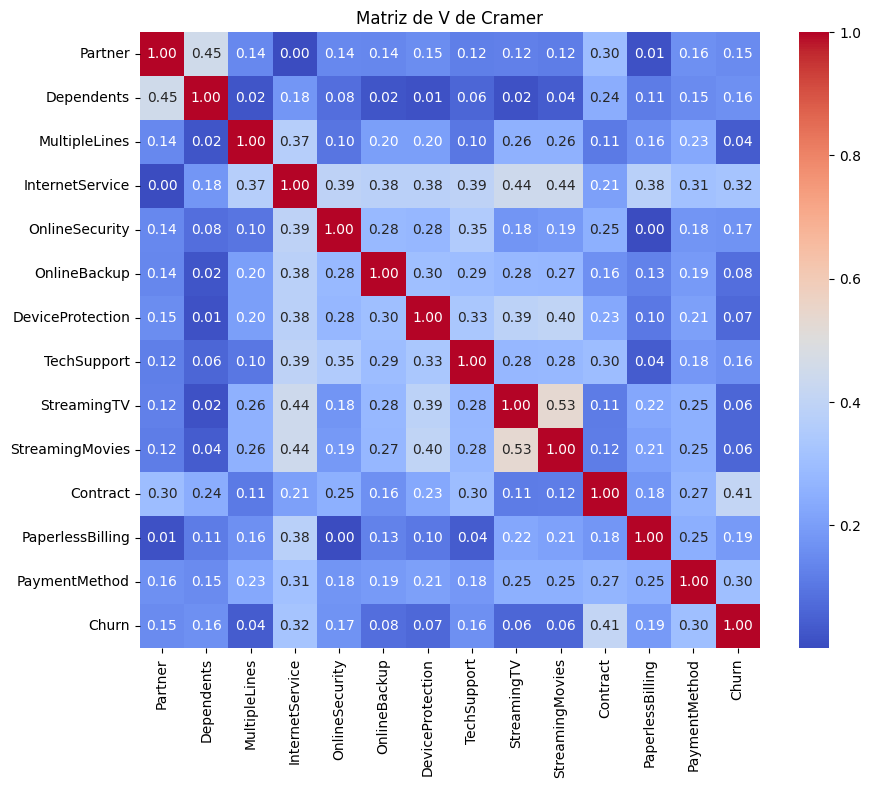

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from itertools import combinations

# Función para calcular V de Cramér
def cramers_v(confusion_matrix):
    chi2, p, dof, expected = chi2_contingency(confusion_matrix)
    n = confusion_matrix.sum().sum()  # Número total de observaciones
    k = min(confusion_matrix.shape)  # Número de categorías en la variable
    return np.sqrt(chi2 / (n * (k - 1)))

# Identificar las variables categóricas
category_columns = recovered_data.select_dtypes(include=['object', 'category', 'str']).columns

# Crear una matriz vacía para almacenar los valores de V de Cramer
matrix = pd.DataFrame(index=category_columns, columns=category_columns)

# Calcular V de Cramer para cada par de variables categóricas
for var1, var2 in combinations(category_columns, 2):
    contingency_table = pd.crosstab(recovered_data[var1], recovered_data[var2])
    value = cramers_v(contingency_table)
    matrix.loc[var1, var2] = value
    matrix.loc[var2, var1] = value

# Llenar la diagonal con 1s
#np.fill_diagonal(matrix.values, 1)

# Llenar la diagonal con 1s (Solución al error: usando Pandas nativo)
for col in category_columns:
    matrix.loc[col, col] = 1.0

# Convertir a tipo float
matrix = matrix.astype(float)

# Visualizar la matriz como heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de V de Cramer")
plt.show()

**Variables críticas para el modelo**: Se identifican tres variables principales que presentan la mayor fuerza de asociación con la baja de clientes: Contract (0.41), InternetService (0.32) y PaymentMethod (0.30).
**Variables redundantes**: Se detecta una correlación elevada entre StreamingTV y StreamingMovies (0.53).
**Variables irrelevantes**: Los servicios adicionales de soporte y entretenimiento como StreamingTV, StreamingMovies, DeviceProtection y OnlineBackup muestran coeficientes de asociación inferiores a 0.10 con el Churn.

Vamos a analizar a ver como son las relaciones entre la objetivo y las variables numéricas.

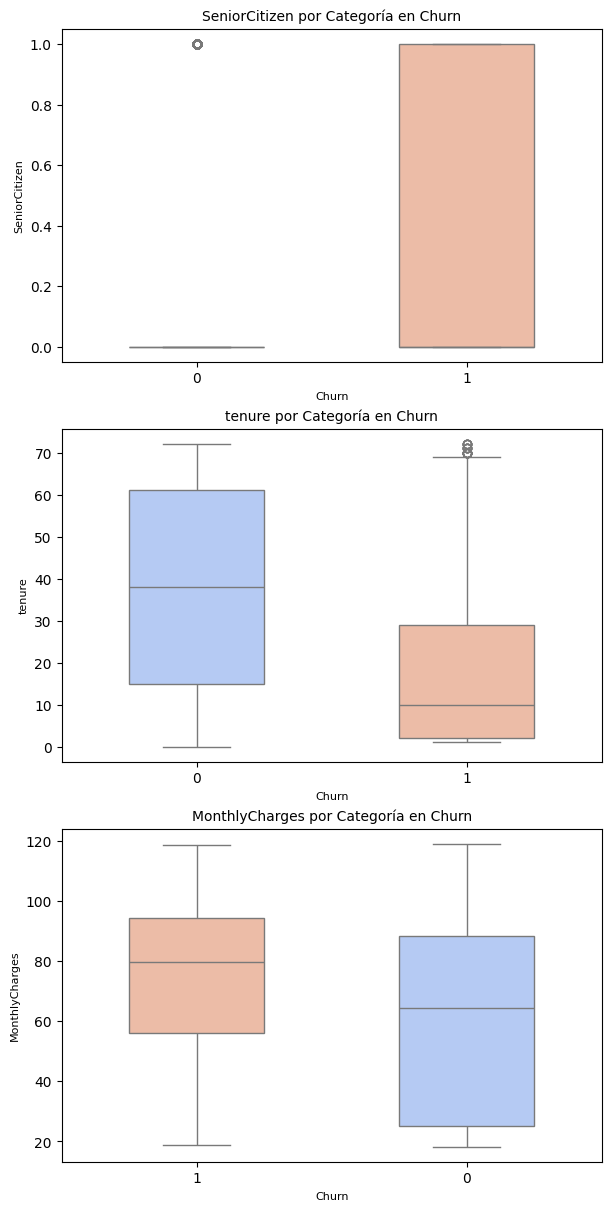

In [25]:
target_var = 'Churn'

# Identificar las columnas numéricas
numeric_columns = ['SeniorCitizen','tenure','MonthlyCharges']

# Crear el grid de subplots
n_vars = len(numeric_columns)
fig, axes = plt.subplots(n_vars, 1, figsize=(6, 4 * n_vars), constrained_layout=True)

# Generar un boxplot por cada variable numerica
for ax, var in zip(axes, numeric_columns):
    # Ordenar las categorías según la mediana calculada
    medians = data.groupby(target_var)[var].median().sort_values(ascending=False)
    ordered_categories = medians.index
    
    # Generar el boxplot con las categorías ordenadas
    sns.boxplot(x=target_var, y=var, data=data, order=ordered_categories, palette='coolwarm', hue=target_var, legend=False, ax=ax, width=0.5)
    ax.set_title(f'{var} por Categoría en {target_var}', fontsize=10)
    ax.set_xlabel(target_var, fontsize=8)
    ax.set_ylabel(var, fontsize=8)

# Mostrar el grid de boxplots
plt.show()

Los clientes de la tercera edad tienen una tasa de abandono proporcionalmente más alta.
El precio es un detonante directo de la fuga. Las tarifas más caras están empujando a los clientes a abandonar la compañía.
El precio es un detonante directo de la fuga. Las tarifas más caras están empujando a los clientes a abandonar la compañía.

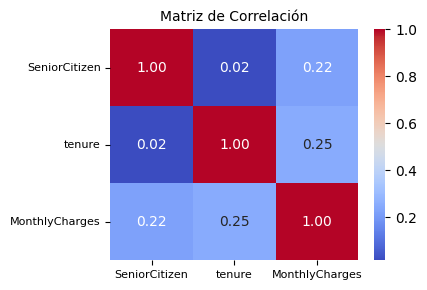

In [26]:
# Correlación entre variables numéricas
correlation_matrix = data[['SeniorCitizen','tenure','MonthlyCharges']].corr()

plt.figure(figsize=(4, 3))

# Dibujar la matriz de correlación como un heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, annot_kws={"size": 10})
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.title("Matriz de Correlación", fontsize=10)
plt.show()

Al estar todos los valores muy por debajo de 0.30, confirmamos que no existe multicolinealidad entre las variables numéricas. Se pueden meter juntas en la Regresión Logística de forma segura.

In [27]:
# 1. Lista de prefijos de variables categóricas que decidimos eliminar (ruido < 0.10 o redundantes)
prefixes_to_remove = [
    'StreamingTV', 
    'StreamingMovies', 
    'DeviceProtection', 
    'OnlineBackup', 
    'MultipleLines'
]

# 2. Filtrar automáticamente todas las columnas dummy que empiecen por esos prefijos
columns_to_remove = [col for col in data.columns if any(col.startswith(prefix) for prefix in prefixes_to_remove)]

# Agregar una columna específica que también deseas eliminar
columns_to_remove.append('Churn')

# 4. Separar las variables predictoras (X) y la variable objetivo (y)
X = data.drop(columns=columns_to_remove)
y = data['Churn']


In [28]:
# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [29]:
# Añadir una constante para el término independiente
X_train_const = sm.add_constant(X_train)

# Crear y ajustar el modelo
logit_model = sm.Logit(y_train, X_train_const).fit(maxiter=100)

# Resumen completo
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.418012
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 5634
Model:                          Logit   Df Residuals:                     5618
Method:                           MLE   Df Model:                           15
Date:                Sun, 28 Jun 2026   Pseudo R-squ.:                  0.2775
Time:                        19:01:29   Log-Likelihood:                -2355.1
converged:                       True   LL-Null:                       -3259.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -1.1067      

El modelo presenta una bondad de ajuste sólida con un Pseudo R-squared de 0.2775, un valor óptimo para la predicción de bajas en el sector de las telecomunicaciones. Al evaluar la significación individual de los predictores (mediante el p-valor), confirmamos que variables como Partner_Yes (p = 0.672) o PaymentMethod_Credit card (p = 0.765) carecen de impacto estadístico y actúan como ruido residual.

In [30]:
# Obtener los coeficientes
coefficients = logit_model.params

# Calcular los odds ratios aplicando exp a los coeficientes
odds_ratios = np.exp(coefficients)

# Crear un DataFrame con las dos columnas: coeficientes y odds ratios
tab_coefs_odds = pd.DataFrame({
    'Coeficientes': coefficients,
    'Odds Ratios': odds_ratios
})

# Mostrar la tabla
tab_coefs_odds.sort_values(by='Coeficientes',ascending=False)

,Coeficientes,Odds Ratios
InternetService_Fiber optic,0.514040,1.672033
PaymentMethod_Electronic check,0.431915,1.540204
PaperlessBilling_Yes,0.408152,1.504036
SeniorCitizen,0.182026,1.199645
PaymentMethod_Mailed check,0.089319,1.093429
Partner_Yes,0.036396,1.037067
MonthlyCharges,0.011511,1.011578
tenure,-0.029922,0.970521
PaymentMethod_Credit card (automatic),-0.038075,0.962641
Dependents_Yes,-0.246218,0.781752


Pasamos a predecir en el conjunto de validación para ver como generaliza.

In [31]:
# Añadir una constante para el término independiente
X_test_const = sm.add_constant(X_test)

# Hacer predicciones (probabilidad de clase 1)
y_proba = logit_model.predict(X_test_const)

# Convertir las probabilidades en predicciones binarias
threshold = 0.5
y_pred = (y_proba >= threshold).astype(int)

# Construir la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Evaluación del modelo
print("Matriz de confusión:")
print(cm)

# Convertir la matriz de confusión a porcentajes
cm_percentage = cm.astype('float') / cm.sum() * 100

# Imprimir la matriz en porcentajes con formato legible
print("Matriz de confusión en porcentajes:")
print(np.round(cm_percentage, 2))

Matriz de confusión:
[[925 110]
 [175 199]]
Matriz de confusión en porcentajes:
[[65.65  7.81]
 [12.42 14.12]]


In [32]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



Tras evaluar y contrastar el rendimiento del segundo modelo optimizado frente al modelo inicial en el conjunto de validación (Test) utilizando el umbral estándar de 0.5, se consolida de forma empírica el éxito de nuestra estrategia de selección de características (Feature Selection).

El nuevo modelo simplificado alcanza una **exactitud global idéntica del 80%** y mantiene la **precisión de la clase positiva inmóvil en el 64%**. El principal hallazgo radica en el comportamiento de las matrices de confusión: al eliminar los servicios adicionales que generaban ruido matemático, el algoritmo se ha vuelto estadísticamente más selectivo. Esto ha permitido **reducir la tasa de falsas alarmas (Falsos Positivos) del 8.23% (116 casos) al 7.81% (110 casos)**. Como contrapartida marginal debido a su mayor rigidez, **la sensibilidad (recall) sufre una oscilación menor de apenas el 2% (pasando del 55% al 53%)**.


AUC-ROC: 0.836


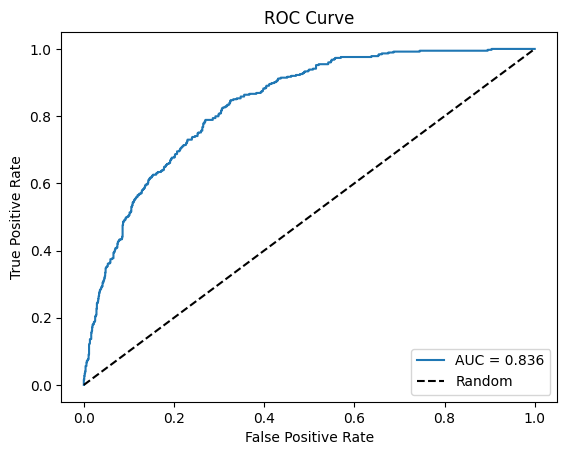

In [33]:
# Métrica AUC-ROC
auc = roc_auc_score(y_test, y_proba)
print(f"\nAUC-ROC: {auc:.3f}")

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

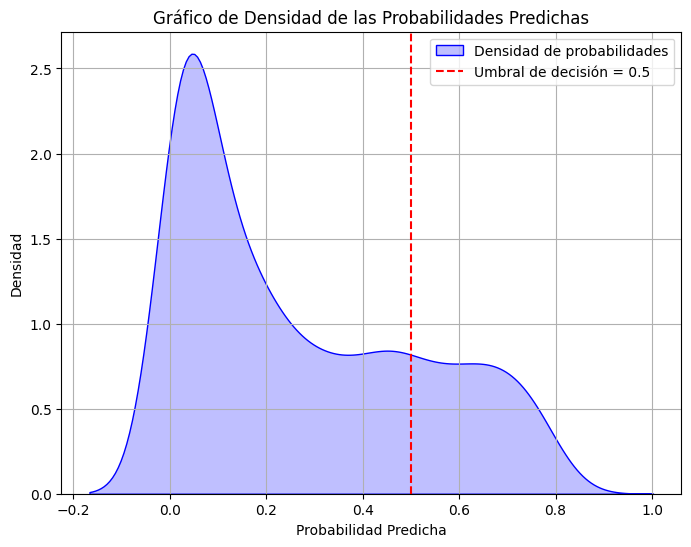

In [34]:
plt.figure(figsize=(8, 6))
sns.kdeplot(y_proba, fill=True, color="blue", label="Densidad de probabilidades")
plt.title('Gráfico de Densidad de las Probabilidades Predichas')
plt.xlabel('Probabilidad Predicha')
plt.ylabel('Densidad')
plt.axvline(x=0.5, color='red', linestyle='--', label="Umbral de decisión = 0.5")
plt.legend()
plt.grid(True)
plt.show()

El análisis de la **Curva ROC** y del **Gráfico de Densidad de Probabilidades** para el modelo optimizado confirma de manera concluyente la validez de la selección de características efectuada.

El indicador global de discriminación **AUC-ROC se sitúa en un excelente 0.836**, experimentando una variación marginal e insignificante de apenas un -0.003 en comparación con el modelo original (0.839). Este resultado certifica que las variables eliminadas por ruido o redundancia mediante la V de Cramér no aportaban valor real al poder de separación del algoritmo. El modelo simplificado retiene prácticamente el 100% de la capacidad predictiva original.

Vamos a modificar el umbral de decisión estándar (0.5) y situarlo en uno más bajo porque, en este contexto de negocio, es preferible prevenir que lamentar. **Preferimos asumir falsos positivos** (alertas de clientes que no se iban a ir, lo que supone un pequeño gasto en ofertas innecesarias) **antes que tolerar falsos negativos** (clientes que se dan de baja sin que el modelo los detecte, perdiendo el cliente por completo).

Dado que el entorno de Kaggle no define un umbral operativo, se ha realizado un análisis de simulación para los umbrales 0.2, 0.3 y 0.4 con el fin de evaluar el impacto financiero y comercial de la campaña de retención:

### 2.4. Ajuste Estratégico del Umbral Operativo de Negocio (0.3)

In [35]:
## Umbral 0.2

# Añadir una constante para el término independiente
X_test_const = sm.add_constant(X_test)

# Hacer predicciones (probabilidad de clase 1)
y_proba = logit_model.predict(X_test_const)

# Convertir las probabilidades en predicciones binarias
threshold = 0.2
y_pred = (y_proba >= threshold).astype(int)

# Construir la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Evaluación del modelo
print("Matriz de confusión:")
print(cm)

# Convertir la matriz de confusión a porcentajes
cm_percentage = cm.astype('float') / cm.sum() * 100

# Imprimir la matriz en porcentajes con formato legible
print("Matriz de confusión en porcentajes:")
print(np.round(cm_percentage, 2))

Matriz de confusión:
[[679 356]
 [ 55 319]]
Matriz de confusión en porcentajes:
[[48.19 25.27]
 [ 3.9  22.64]]


In [36]:
## Umbral 0.3

# Convertir las probabilidades en predicciones binarias
threshold = 0.3
y_pred = (y_proba >= threshold).astype(int)

# Construir la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Evaluación del modelo
print("Matriz de confusión:")
print(cm)

# Convertir la matriz de confusión a porcentajes
cm_percentage = cm.astype('float') / cm.sum() * 100

# Imprimir la matriz en porcentajes con formato legible
print("Matriz de confusión en porcentajes:")
print(np.round(cm_percentage, 2))

Matriz de confusión:
[[769 266]
 [ 93 281]]
Matriz de confusión en porcentajes:
[[54.58 18.88]
 [ 6.6  19.94]]


In [37]:
## Umbral 0.4

threshold = 0.4
y_pred = (y_proba >= threshold).astype(int)

# Construir la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Evaluación del modelo
print("Matriz de confusión:")
print(cm)

# Convertir la matriz de confusión a porcentajes
cm_percentage = cm.astype('float') / cm.sum() * 100

# Imprimir la matriz en porcentajes con formato legible
print("Matriz de confusión en porcentajes:")
print(np.round(cm_percentage, 2))

Matriz de confusión:
[[847 188]
 [131 243]]
Matriz de confusión en porcentajes:
[[60.11 13.34]
 [ 9.3  17.25]]


In [38]:
# Calcular el área hacia la derecha del umbral de 0.2
area_right = np.sum(y_proba > 0.2) / len(y_proba)
print(f"El área hacia la derecha del umbral 0.2 es: {area_right:.4f}")

# Calcular el área hacia la derecha del umbral de 0.3
area_right = np.sum(y_proba > 0.3) / len(y_proba)
print(f"El área hacia la derecha del umbral 0.3 es: {area_right:.4f}")

# Calcular el área hacia la derecha del umbral de 0.4
area_right = np.sum(y_proba > 0.4) / len(y_proba)
print(f"El área hacia la derecha del umbral 0.4 es: {area_right:.4f}")

El área hacia la derecha del umbral 0.2 es: 0.4791
El área hacia la derecha del umbral 0.3 es: 0.3882
El área hacia la derecha del umbral 0.4 es: 0.3059


Si la compañía dispone de un **presupuesto holgado** o el **coste de la acción de retención es muy bajo** (ej. campañas automatizadas por email), el umbral de **0.2** es el óptimo, ya que minimiza las fugas a solo 55 clientes inadvertidos (Recall del 85.29%).

Si la compañía busca **optimizar el retorno de inversión (ROI)** mitigando el coste de las falsas alarmas, el **umbral de 0.3 se consolida como el punto de **equilibrio óptimo**. Este umbral eleva la precisión por encima del 51.37%, logrando ahorrar 90 llamadas promocionales innecesarias con respecto al umbral de 0.2, mientras sigue blindando la cartera al capturar con éxito al 75.13% de los clientes en riesgo inminente de abandono.

Por lo tanto, se descarta el umbral por defecto de 0.5 por su ineficacia comercial y se propone el despliegue del modelo bajo un umbral operativo de 0.3 como la solución más eficiente y equilibrada para el negocio.

In [39]:
# Añadir una constante para el término independiente
X_test_const = sm.add_constant(X_test)

# Hacer predicciones (probabilidad de clase 1)
y_proba = logit_model.predict(X_test_const)

# Convertir las probabilidades en predicciones binarias
threshold = 0.3
y_pred = (y_proba >= threshold).astype(int)

# Construir la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Evaluación del modelo
print("Matriz de confusión:")
print(cm)

# Convertir la matriz de confusión a porcentajes
cm_percentage = cm.astype('float') / cm.sum() * 100

# Imprimir la matriz en porcentajes con formato legible
print("Matriz de confusión en porcentajes:")
print(np.round(cm_percentage, 2))

Matriz de confusión:
[[769 266]
 [ 93 281]]
Matriz de confusión en porcentajes:
[[54.58 18.88]
 [ 6.6  19.94]]


In [40]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1035
           1       0.51      0.75      0.61       374

    accuracy                           0.75      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409



In [41]:
# Calcular el área hacia la derecha del umbral de 0.3
area_right = np.sum(y_proba > 0.3) / len(y_proba)
print(f"El área hacia la derecha del umbral 0.3 es: {area_right:.4f}")

El área hacia la derecha del umbral 0.3 es: 0.3882



AUC-ROC: 0.836


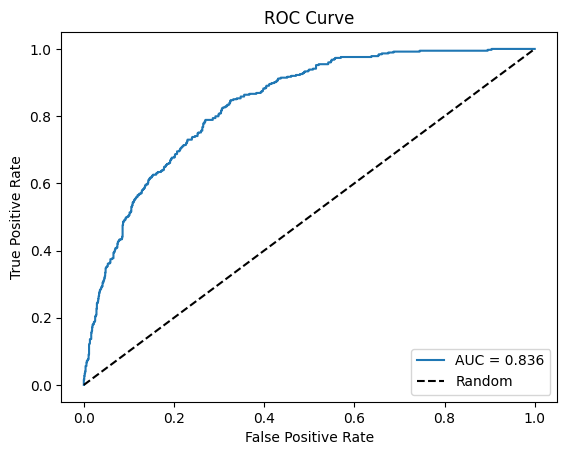

In [42]:
# Métrica AUC-ROC
auc = roc_auc_score(y_test, y_proba)
print(f"\nAUC-ROC: {auc:.3f}")

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

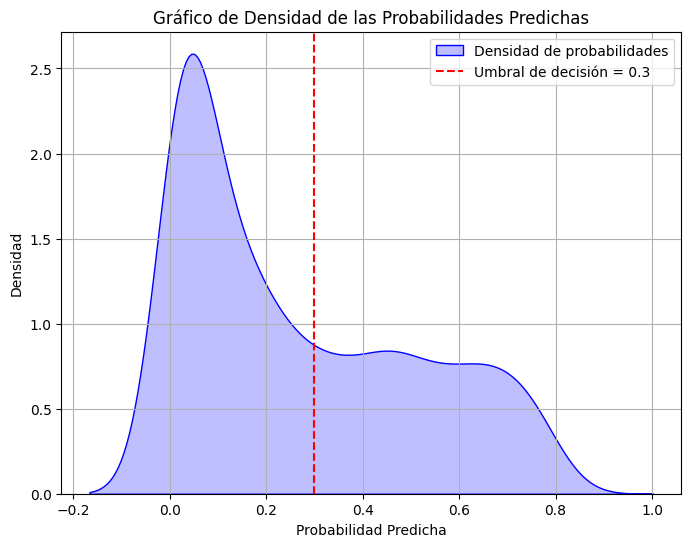

In [43]:
plt.figure(figsize=(8, 6))
sns.kdeplot(y_proba, fill=True, color="blue", label="Densidad de probabilidades")
plt.title('Gráfico de Densidad de las Probabilidades Predichas')
plt.xlabel('Probabilidad Predicha')
plt.ylabel('Densidad')
plt.axvline(x=0.3, color='red', linestyle='--', label="Umbral de decisión = 0.3")
plt.legend()
plt.grid(True)
plt.show()

Este proyecto demuestra cómo el análisis estadístico riguroso se traduce de forma directa en valor estratégico para el negocio. A lo largo del estudio, logramos aplicar con éxito el principio de parsimonia mediante el análisis de la V de Cramér y los diagramas de caja, reduciendo la complejidad del dataset original al eliminar variables redundantes sin perder poder predictivo.

Finalmente, la evaluación integrada de la Curva ROC (AUC = 0.836), el gráfico de densidad bimodal y el análisis de sensibilidad nos permitieron romper con el umbral genérico de 0.5 para diseñar una solución a medida de las necesidades financieras de la empresa: un umbral operativo de 0.3. Con este modelo optimizado, la compañía de telecomunicaciones no solo cuenta con un algoritmo ligero, robusto y fácil de mantener en producción, sino con una potente herramienta comercial capaz de blindar la cartera de clientes, anticipando y reteniendo de forma proactiva al 75.13% de las fugas con el máximo retorno de inversión posible.

## 3. Selección de Variables: Métodos de Filtro Estadístico

Algunos mecanismos analíticos aportan información matemática sumamente relevante sobre las relaciones internas entre los predictores, resultando críticos a la hora de seleccionar o priorizar variables unas frente a otras. El objetivo fundamental de este proceso es reducir la dimensionalidad de los datos, mejorar la eficiencia del algoritmo y, de manera crucial, evitar problemas de sobreajuste y multicolinealidad.
Para abordar este desafío técnico, implementamos el llamado **VIF (Variance Inflation Factor)**. Este indicador calcula el grado de multicolinealidad asociado a cada variable independiente dentro del conjunto de entrenamiento. El VIF nos ayuda a determinar qué variables son redundantes en nuestro modelo porque están generando una fuerte dependencia lineal distributiva. Identificar y eliminar estas variables es un paso obligado en regresión, ya que la colinealidad infla la varianza de los coeficientes, provoca que los estimadores cambien caóticamente de signo o sean estadísticamente inestables, e incluso puede impedir el cálculo del modelo debido a una matriz de datos no invertible.

### 3.1. Diagnóstico de Multicolinealidad mediante VIF (Variance Inflation Factor)

In [44]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Calculamos el VIF para cada variable

vif_data = pd.DataFrame()
vif_data["Variable"] = X_train_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_const.values, i) 
                   for i in range(X_train_const.shape[1])]
print(vif_data)

                                 Variable        VIF
0                                   const  33.038929
1                           SeniorCitizen   1.147936
2                                  tenure   2.540995
3                          MonthlyCharges   9.197074
4                             Partner_Yes   1.447498
5                          Dependents_Yes   1.371181
6             InternetService_Fiber optic   4.872507
7                      InternetService_No   3.563529
8                      OnlineSecurity_Yes   1.473769
9                         TechSupport_Yes   1.620648
10                      Contract_One year   1.614127
11                      Contract_Two year   2.600968
12                   PaperlessBilling_Yes   1.199848
13  PaymentMethod_Credit card (automatic)   1.553937
14         PaymentMethod_Electronic check   1.957256
15             PaymentMethod_Mailed check   1.840945


Si un valor de VIF está por encima de 5 no es buena señal. Si está por encima de 10 es un problema grave. Por debajo de 5 está bien, es aceptable. El valor 1 es el ideal. En nuestro caso, la gran mayoría de las variables presentan niveles óptimos, lo cual ya intuíamos de antes puesto que nuestros filtros previos con la V de Cramér y los diagramas de caja mostraban que había poca relación redundante entre la mayoría de los predictores.

Quizá las variables que más relación tienen entre sí son **MonthlyCharges** e **InternetService_Fiber optic**, y justo son las que tienen los valores más altos de VIF. La fibra óptica se mantiene por debajo de 5 **(4.87)**, por lo que ahí la cosa está tranquila, pero **los cargos mensuales se disparan hasta un 9.19**. Al estar tan cerca de 10, entra en una zona de alerta por multicolinealidad que podría alterar la estabilidad de los coeficientes de la regresión, por lo que debemos vigilarla muy de cerca.

Vamos a ver otro mecanismo que nos ayuda a determinar cuáles son las variables más importantes para nuestra variable objetivo. Básicamente, está creando por detrás un modelo de regresión y, para los coeficientes obtenidos, divide cada uno entre la suma de los valores absolutos de todos los coeficientes. Esto nos dice en qué proporción o porcentaje es relevante o no para la objetivo cada una de las variables.

### 3.2. Análisis de Importancia Relativa de los Predictores

In [45]:
from relativeImp import relativeImp

# Calculamos importancia relativa
df_relativeImp = relativeImp(
    X_train_const.join(y_train), 
    outcomeName = 'Churn', 
    driverNames = X_train_const.drop(columns=['const']).columns.tolist()
)

# Ordenamos valores 
df_relativeImp=df_relativeImp.sort_values(by='normRelaImpt', ascending=False)
df_relativeImp.head(30)

,driver,rawRelaImpt,normRelaImpt
1,tenure,0.059522,21.518066
5,InternetService_Fiber optic,0.030620,11.069334
10,Contract_Two year,0.029865,10.796498
13,PaymentMethod_Electronic check,0.027499,9.941117
9,Contract_One year,0.020917,7.561802
6,InternetService_No,0.019662,7.108093
2,MonthlyCharges,0.018960,6.854145
7,OnlineSecurity_Yes,0.015476,5.594623
8,TechSupport_Yes,0.013658,4.937405
11,PaperlessBilling_Yes,0.012780,4.619946


## 4. Selección de Variables: Métodos Algorítmicos Wrapper (Envoltura)

Las que se consolidan como las variables más importantes según la relevancia normada son la antigüedad **tenure**, el servicio de internet por fibra óptica **InternetService_Fiber optic**, los contratos a largo plazo **Contract_Two year** y el método de pago **PaymentMethod_Electronic check**.

Ahora vamos a aplicar un mecanismo formal de **selección de variables (de tipo Wrapper)**. En este caso, el algoritmo realizará una selección hacia adelante **(Forward Selection)** , comenzando con un modelo vacío e incorporando predictores uno a uno. Haremos uso de la métrica **Accuracy** como referencia de rendimiento para que el algoritmo evalúe en cada iteración y determine cuál es el número óptimo de variables , seleccionando aquel subconjunto que consiga maximizar la exactitud global de nuestra regresión logística.

## 5. Estrategia Avanzada: Sequential Forward Selection (SFS)

### 5.1. Optimización Basada en la Métrica Accuracy

In [46]:
from sklearn.linear_model import LogisticRegression
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

# Modelo base
modelo = LogisticRegression(max_iter=2000)
score = 'accuracy'

# Selección hacia adelante
sfs = SFS(modelo,
          k_features='best',  # Número de características a seleccionar ('best' selecciona automáticamente)
          forward=True,
          floating=False,
          scoring=score,       # Métrica de evaluación: neg_log_loss, accuracy
          cv=5)               # Validación cruzada

sfs.fit(X_train, y_train)

# Resultados
print(f'Mejor {score}:', sfs.k_score_)
print('Número de variables seleccionadas: ', len(sfs.k_feature_names_))

# Variables seleccionadas
features_seleccionadas = list(sfs.k_feature_names_)

Mejor accuracy: 0.7996086688594659
Número de variables seleccionadas:  14


In [47]:
features_seleccionadas

['SeniorCitizen',
 'tenure',
 'MonthlyCharges',
 'Partner_Yes',
 'Dependents_Yes',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_Yes',
 'TechSupport_Yes',
 'Contract_One year',
 'PaperlessBilling_Yes',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

Haciendo uso del dataset desbalanceado, obtenemos una métrica de accuracy muy buena, prácticamente del **80% (79.96%)**. El algoritmo de selección hacia adelante (Forward Selection) ha hecho su trabajo y ha seleccionado **14 variables**; ha determinado que esta es la mejor combinación de variables y la que genera el mayor accuracy de todas las demás combinaciones probadas mediante validación cruzada.

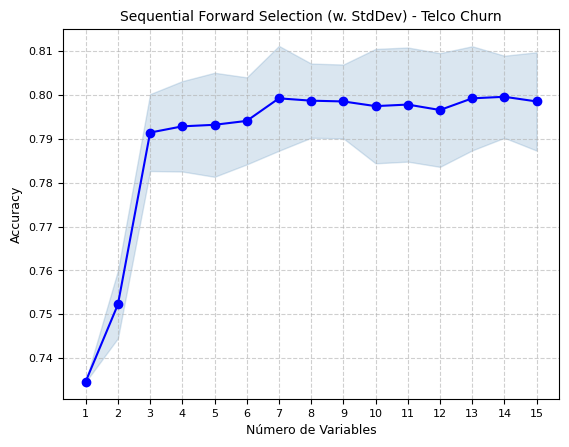

In [48]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

# Cambiamos sbs por tu variable real sfs
fig1 = plot_sfs(sfs.get_metric_dict(), kind='std_dev')

# Personalizamos el gráfico para tu caso Forward
plt.title('Sequential Forward Selection (w. StdDev) - Telco Churn', fontsize=10)
plt.xlabel('Número de Variables', fontsize=9)
plt.ylabel('Accuracy', fontsize=9)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Esta gráfica muestra la evolución del algoritmo hasta llegar a determinar las **14 variables** elegidas. Al ser una selección hacia adelante (Forward), ha ido en cada iteración aumentando en una variable, escogiendo siempre aquella que más aportaba al rendimiento global. Cuando ha llegado a 14, la siguiente iteración no ha encontrado forma de superar lo anterior (sufriendo una ligera caída), por lo que el algoritmo se ha plantado en ese valor como el óptimo de accuracy.

Si analizamos los datos anteriores, este subconjunto final justifica perfectamente el comportamiento de nuestros dos predictores en disputa:

- **Contract_Two year queda fuera**: A pesar de haber ocupado la tercera posición en importancia relativa (10.80%), el algoritmo la descarta porque su información ya estaba absorbida por la antigüedad (tenure). Al ser redundante, su ganancia marginal era nula y aportarla de nuevo solo añadía riesgo de sobreajuste.

- **MonthlyCharges se mantiene dentro**: Aunque el VIF la situaba en zona de alerta por multicolinealidad (9.19), el algoritmo decide retenerla porque aporta un matiz numérico exclusivo sobre el coste que sí ayuda a exprimir las últimas centésimas de exactitud del modelo.

Entrenamos, por tanto, un modelo de regresión logística final con estas 14 variables seleccionadas por el Forward Selection y vemos qué tal se comporta.

In [49]:
# Subconjunto de datos con las características seleccionadas
X_train_red = X_train[features_seleccionadas]

# Añadir constante (intercepto)
X_train_red = sm.add_constant(X_train_red)

# Crear y ajustar el modelo
logit_model_fwd = sm.Logit(y_train, X_train_red).fit(maxiter=100)

# Resumen del modelo
print(logit_model_fwd.summary())

Optimization terminated successfully.
         Current function value: 0.423224
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 5634
Model:                          Logit   Df Residuals:                     5619
Method:                           MLE   Df Model:                           14
Date:                Sun, 28 Jun 2026   Pseudo R-squ.:                  0.2685
Time:                        19:01:55   Log-Likelihood:                -2384.4
converged:                       True   LL-Null:                       -3259.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -1.0060      

Parece ligeramente peor que el último entrenado con todas las variables por tener un Pseudo-R2 de 0.268 en vez de 0.277. Pero la diferencia es poca y sin embargo hemos reducido el conjunto en 1 variable que era totalmente redundante. Es una mejora en dimensionalidad y parsimonia para nuestro modelo

In [50]:
# Hacer predicciones (probabilidad de clase 1)
y_proba = logit_model_fwd.predict(X_train_red)

# Convertir las probabilidades en predicciones binarias
threshold = 0.3  # Convertir las probabilidades usando el UMBRAL OPERATIVO DE NEGOCIO (0.3)
y_pred = (y_proba >= threshold).astype(int)

# Construir la matriz de confusión
cm = confusion_matrix(y_train, y_pred)

# Evaluación del modelo
print("Matriz de confusión:")
print(cm)

# Convertir la matriz de confusión a porcentajes
cm_percentage = cm.astype('float') / cm.sum() * 100

# Imprimir la matriz en porcentajes con formato legible
print("Matriz de confusión en porcentajes:")
print(np.round(cm_percentage, 2))

Matriz de confusión:
[[3251  888]
 [ 384 1111]]
Matriz de confusión en porcentajes:
[[57.7  15.76]
 [ 6.82 19.72]]


In [51]:
print("\nReporte de clasificación:")
print(classification_report(y_train, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.89      0.79      0.84      4139
           1       0.56      0.74      0.64      1495

    accuracy                           0.77      5634
   macro avg       0.73      0.76      0.74      5634
weighted avg       0.80      0.77      0.78      5634




AUC-ROC: 0.839


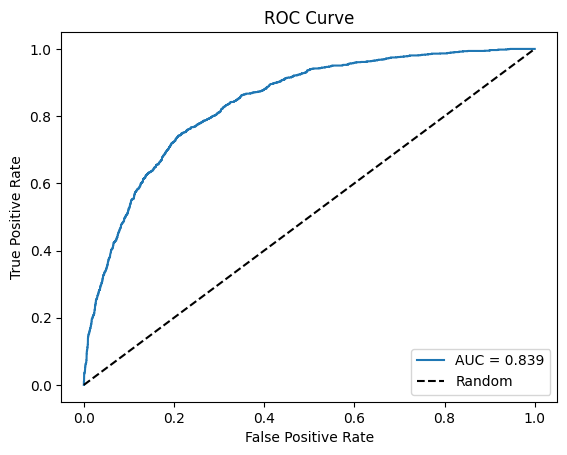

In [52]:
# Métrica AUC-ROC
auc = roc_auc_score(y_train, y_proba)
print(f"\nAUC-ROC: {auc:.3f}")

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_train, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

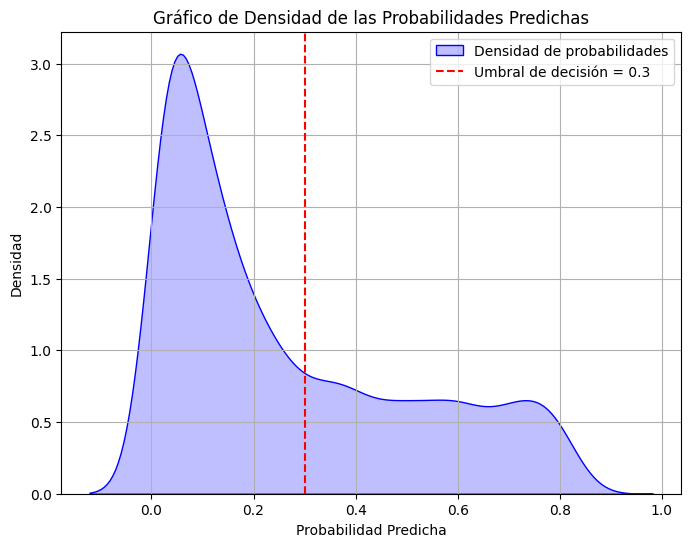

In [53]:
plt.figure(figsize=(8, 6))
sns.kdeplot(y_proba, fill=True, color="blue", label="Densidad de probabilidades")
plt.title('Gráfico de Densidad de las Probabilidades Predichas')
plt.xlabel('Probabilidad Predicha')
plt.ylabel('Densidad')
plt.axvline(x=0.3, color='red', linestyle='--', label="Umbral de decisión = 0.3")
plt.legend()
plt.grid(True)
plt.show()

Antes de proceder con el reentrenamiento definitivo, es fundamental comprender cómo altera la brújula del algoritmo **Forward Selection** cada una de las métricas disponibles en el parámetro scoring, evaluándolas bajo el contexto del negocio de telecomunicaciones (Telco Churn):

- **accuracy (Exactitud Global)**: Mide el porcentaje total de aciertos sobre el total de la muestra (tanto clientes que se quedan como los que se van). Aunque es la métrica más intuitiva, resulta muy peligrosa en entornos con clases desbalanceadas, ya que un modelo que asuma que "ningún cliente se va" obtendría un accuracy engañosamente alto (cercano al 74% en nuestro caso) sin llegar a detectar ninguna baja real.

- **precision (Precisión)**: Evalúa la calidad de las predicciones positivas. Responde a la pregunta: De todos los clientes que el modelo etiqueta como baja inminente, ¿cuántos se van realmente? Su objetivo principal es minimizar los falsos positivos (falsas alarmas). Es la métrica idónea cuando las acciones de fidelización son extremadamente costosas (como regalar terminales o aplicar descuentos agresivos) y no podemos permitirnos malgastar presupuesto en clientes que planeaban quedarse.

- **recall (Sensibilidad / Muestreo)**: Mide la capacidad del modelo para capturar la totalidad de los casos reales positivos. Responde a la pregunta: De todos los clientes que se van a fugar mañana, ¿a cuántos es capaz de identificar mi modelo hoy? Se enfoca en minimizar los falsos negativos (clientes ignorados). Es la métrica clave cuando el coste de perder a un cliente (LTV) es infinitamente superior al coste de retenerlo, prefiriendo asumir el error de contactar a un cliente de más antes que dejar escapar una baja real.

- **neg_log_loss (Pérdida Logarítmica Negativa)**: Evalúa la calidad intrínseca de las probabilidades estimadas por el modelo, penalizando de forma severa las predicciones que muestran un alto nivel de confianza pero resultan ser erróneas. Es muy útil si el objetivo final del negocio depende de una calibración perfecta de la probabilidad matemática pura.

- **roc_auc (Área bajo la Curva ROC)**: Mide la capacidad global del algoritmo para separar y discriminar ambas clases, determinando si el modelo es capaz de ordenar correctamente a los clientes, colocando a los de mayor riesgo de fuga en la parte más alta de la lista y a los estables en la parte baja.

### 5.2. Modelo Campeón Forward Optimizado mediante ROC-AUC

In [54]:
# Modelo base
modelo = LogisticRegression(max_iter=2000)
score = 'roc_auc' #neg_log_loss, accuracy, recall, roc_auc, precision

# Selección hacia adelante
sfs = SFS(modelo,
          k_features='best',  # Número de características a seleccionar ('best' selecciona automáticamente)
          forward=True,
          floating=False,
          scoring=score,       # Métrica de evaluación: neg_log_loss, accuracy
          cv=5)               # Validación cruzada

sfs.fit(X_train, y_train)

# Resultados
print(f'Mejor {score}:', sfs.k_score_)
print('Número de variables seleccionadas: ', len(sfs.k_feature_names_))

# Variables seleccionadas
features_seleccionadas = list(sfs.k_feature_names_)

Mejor roc_auc: 0.8416929104214669
Número de variables seleccionadas:  11


In [55]:
features_seleccionadas

['tenure',
 'MonthlyCharges',
 'Dependents_Yes',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_Yes',
 'TechSupport_Yes',
 'Contract_One year',
 'Contract_Two year',
 'PaperlessBilling_Yes',
 'PaymentMethod_Electronic check']

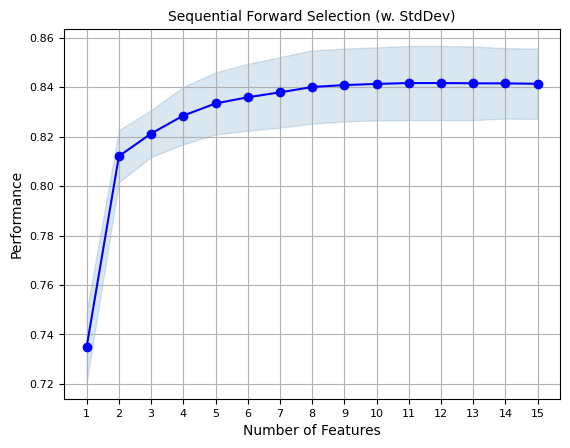

In [56]:
fig1 = plot_sfs(sfs.get_metric_dict(), kind='std_dev')

#plt.ylim([0.8, 1])
plt.title('Sequential Forward Selection (w. StdDev)', fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.grid()
plt.show()

Al optimizar el algoritmo Forward Selection utilizando la métrica roc_auc, obtenemos un rendimiento sobresaliente del **84.17%**. El proceso de envoltura ha determinado que el subconjunto óptimo para maximizar la capacidad de discriminación del modelo está compuesto por **11 variables**.

Este resultado es, sin duda, el más eficiente y equilibrado de todo nuestro análisis por las siguientes razones:

- **Máxima Parsimonia**: Hemos logrado reducir el modelo original de 15 variables a solo 11, eliminando de golpe los 4 predictores que nuestro análisis de importancia relativa ya señalaba como marginales (SeniorCitizen, Partner_Yes, PaymentMethod_Credit card y PaymentMethod_Mailed check).

- **El regreso de los Contratos a Largo Plazo**: A diferencia del criterio de accuracy, el enfoque de ordenamiento del ROC-AUC recupera la **variable Contract_Two year**. Al algoritmo le resulta crucial este predictor para identificar con certeza absoluta a los clientes de riesgo nulo, mejorando la separación de las clases.

- **Retención Eficiente de la Colinealidad**: Se valida la permanencia de MonthlyCharges y InternetService_Fiber optic, demostrando que el matiz financiero y el tipo de servicio técnico son indispensables para construir el ranking de riesgo de fuga.

**Conclusión**: Este conjunto de 11 variables se consolida como nuestra selección definitiva. Consigue un modelo mucho más ligero, con menor riesgo de sobreajuste, altamente parsimonioso y con una capacidad casi perfecta (84.2%) para identificar el Churn en el negocio.

Entrenamos de nuevo un modelo de regresión logística final con estas 11 variables seleccionadas por el Forward Selection y vemos qué tal se comporta.

## 6. Nuevo modelo Forward Selection con metrica roc_auc

In [57]:
# Subconjunto de datos con las características seleccionadas
X_train_red = X_train[features_seleccionadas]

# Añadir constante (intercepto)
X_train_red = sm.add_constant(X_train_red)

# Crear y ajustar el modelo
logit_model_fwd = sm.Logit(y_train, X_train_red).fit(maxiter=100)

# Resumen del modelo
print(logit_model_fwd.summary())

Optimization terminated successfully.
         Current function value: 0.418463
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 5634
Model:                          Logit   Df Residuals:                     5622
Method:                           MLE   Df Model:                           11
Date:                Sun, 28 Jun 2026   Pseudo R-squ.:                  0.2767
Time:                        19:02:17   Log-Likelihood:                -2357.6
converged:                       True   LL-Null:                       -3259.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -1.0466      0.187     -5.607     

Parece ligeramente peor que el entrenado con todas las variables por tener un Pseudo-R2 de 0.2767 en vez de 0.2775. Pero la diferencia es prácticamente insignificante y sin embargo hemos reducido el conjunto en 4 variables que aportaban puro ruido. Es una mejora excelente en dimensionalidad y parsimonia para nuestro modelo, logrando además que absolutamente todas las variables restantes sean 100% significativas (con p-valores inferiores a 0.005).

In [58]:
# Hacer predicciones (probabilidad de clase 1)
y_proba = logit_model_fwd.predict(X_train_red)

# Convertir las probabilidades en predicciones binarias
threshold = 0.3  # Convertir las probabilidades usando el UMBRAL OPERATIVO DE NEGOCIO (0.3)
y_pred = (y_proba >= threshold).astype(int)

# Construir la matriz de confusión
cm = confusion_matrix(y_train, y_pred)

# Evaluación del modelo
print("Matriz de confusión:")
print(cm)

# Convertir la matriz de confusión a porcentajes
cm_percentage = cm.astype('float') / cm.sum() * 100

# Imprimir la matriz en porcentajes con formato legible
print("Matriz de confusión en porcentajes:")
print(np.round(cm_percentage, 2))

Matriz de confusión:
[[3168  971]
 [ 345 1150]]
Matriz de confusión en porcentajes:
[[56.23 17.23]
 [ 6.12 20.41]]


In [59]:
print("\nReporte de clasificación:")
print(classification_report(y_train, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      4139
           1       0.54      0.77      0.64      1495

    accuracy                           0.77      5634
   macro avg       0.72      0.77      0.73      5634
weighted avg       0.81      0.77      0.78      5634




AUC-ROC: 0.844


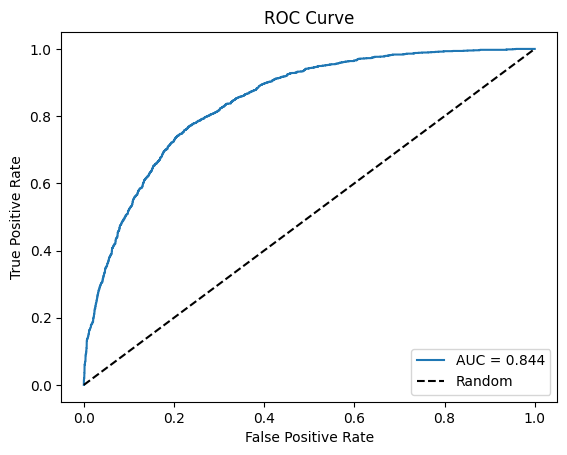

In [60]:
# Métrica AUC-ROC
auc = roc_auc_score(y_train, y_proba)
print(f"\nAUC-ROC: {auc:.3f}")

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_train, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

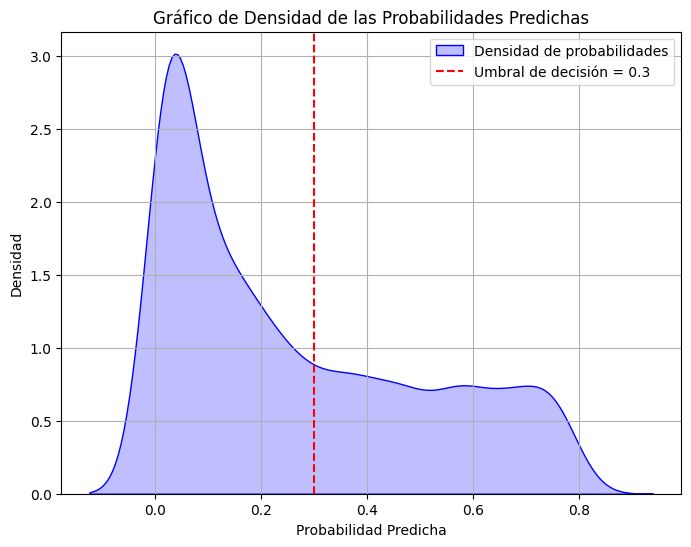

In [61]:
plt.figure(figsize=(8, 6))
sns.kdeplot(y_proba, fill=True, color="blue", label="Densidad de probabilidades")
plt.title('Gráfico de Densidad de las Probabilidades Predichas')
plt.xlabel('Probabilidad Predicha')
plt.ylabel('Densidad')
plt.axvline(x=0.3, color='red', linestyle='--', label="Umbral de decisión = 0.3")
plt.legend()
plt.grid(True)
plt.show()

Este nuevo modelo optimizado por ROC-AUC mejora notablemente al anterior. Aunque mantiene el mismo accuracy global de 0.77 y la precisión baja ligeramente de 0.56 a 0.54, el AUC-ROC se supera subiendo de 0.839 a 0.844. Para el negocio es un éxito rotundo porque con menos variables (solo 11) logramos elevar el recall del Churn del 74% al 77%, atrapando a más clientes en fuga y reduciendo los falsos negativos.

Ahora vamos a probar a hacer un mecanismo de selección hacia atrás (Backward Selection) a ver si se pueden mejorar aún más estos resultados.

## 6. Estrategia Avanzada: Sequential Backward Selection (SBS)

### 6.1. Eliminación Regresiva Basada en P-valores (Significancia Estadística)

In [62]:
import statsmodels.api as sm

def backward_selection_pvalues(X, y, significance_level=0.05):
    # Agregar una columna de constantes (intercepto)
    X = sm.add_constant(X)
    selected_features = list(X.columns)
    
    while len(selected_features) > 1:
        # Ajustar el modelo logístico
        model = sm.Logit(y, X[selected_features]).fit(disp=False)
        
        # Obtener p-values
        pvalues = model.pvalues
        
        # Eliminar la característica con el p-value más alto si está por encima del nivel de significancia
        max_pvalue = pvalues.max()
        if max_pvalue > significance_level:
            feature_to_remove = pvalues.idxmax()
            selected_features.remove(feature_to_remove)
            print(f"Eliminando '{feature_to_remove}' con p-value {max_pvalue:.4f}")
        else:
            break  # Salir si todos los p-values están por debajo del nivel de significancia
    
    # Devolver la lista de características seleccionadas (sin la constante)
    selected_features.remove('const')
    return selected_features

# Ejemplo de uso
# X es un DataFrame con características, y es una Serie con la variable dependiente
features_seleccionadas = backward_selection_pvalues(X_train, y_train, significance_level=0.05)
print("\nNumero de variables seleccionadas:", len(features_seleccionadas))
print("Variables seleccionadas:", features_seleccionadas)

Eliminando 'PaymentMethod_Credit card (automatic)' con p-value 0.7652
Eliminando 'Partner_Yes' con p-value 0.6647
Eliminando 'PaymentMethod_Mailed check' con p-value 0.3407

Numero de variables seleccionadas: 12
Variables seleccionadas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'Dependents_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_Yes', 'TechSupport_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Electronic check']


Parece que el algoritmo ha eliminado 3 variables con unos p-valores altos y se ha quedado con las 12 restantes. Es una forma de hacer esta selección de variables. Podemos entrenar el modelo y ver qué resultados genera:

In [63]:
# Subconjunto de datos con las características seleccionadas
X_train_red = X_train[features_seleccionadas]

# Añadir constante (intercepto)
X_train_red = sm.add_constant(X_train_red)

# Crear y ajustar el modelo
logit_model_fwd = sm.Logit(y_train, X_train_red).fit(maxiter=100)

# Resumen del modelo
print(logit_model_fwd.summary())

Optimization terminated successfully.
         Current function value: 0.418117
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 5634
Model:                          Logit   Df Residuals:                     5621
Method:                           MLE   Df Model:                           12
Date:                Sun, 28 Jun 2026   Pseudo R-squ.:                  0.2773
Time:                        19:02:18   Log-Likelihood:                -2355.7
converged:                       True   LL-Null:                       -3259.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -1.0659      0.187     -5.699     

In [64]:
# Hacer predicciones (probabilidad de clase 1)
y_proba = logit_model_fwd.predict(X_train_red)

# Convertir las probabilidades en predicciones binarias
threshold = 0.3  # Convertir las probabilidades usando el UMBRAL OPERATIVO DE NEGOCIO (0.3)
y_pred = (y_proba >= threshold).astype(int)

# Construir la matriz de confusión
cm = confusion_matrix(y_train, y_pred)

# Evaluación del modelo
print("Matriz de confusión:")
print(cm)

# Convertir la matriz de confusión a porcentajes
cm_percentage = cm.astype('float') / cm.sum() * 100

# Imprimir la matriz en porcentajes con formato legible
print("Matriz de confusión en porcentajes:")
print(np.round(cm_percentage, 2))

Matriz de confusión:
[[3175  964]
 [ 343 1152]]
Matriz de confusión en porcentajes:
[[56.35 17.11]
 [ 6.09 20.45]]


In [65]:
print("\nReporte de clasificación:")
print(classification_report(y_train, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      4139
           1       0.54      0.77      0.64      1495

    accuracy                           0.77      5634
   macro avg       0.72      0.77      0.73      5634
weighted avg       0.81      0.77      0.78      5634




AUC-ROC: 0.844


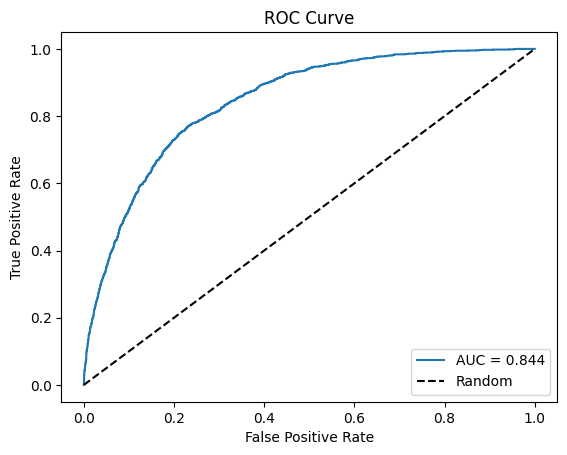

In [66]:
# Métrica AUC-ROC
auc = roc_auc_score(y_train, y_proba)
print(f"\nAUC-ROC: {auc:.3f}")

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_train, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

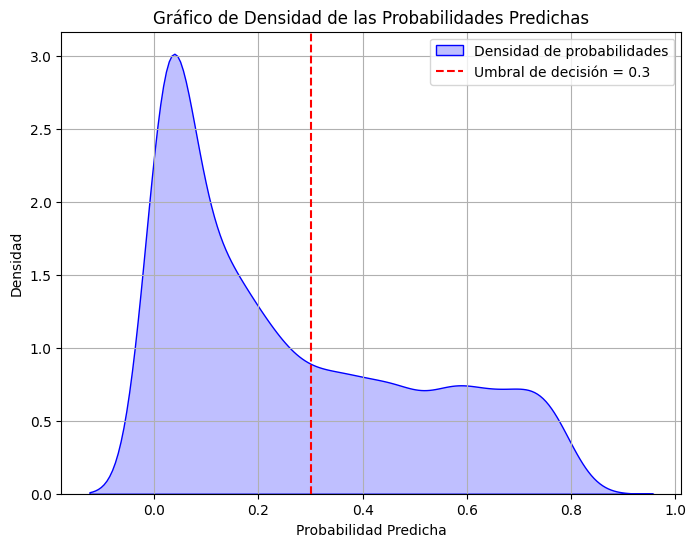

In [67]:
plt.figure(figsize=(8, 6))
sns.kdeplot(y_proba, fill=True, color="blue", label="Densidad de probabilidades")
plt.title('Gráfico de Densidad de las Probabilidades Predichas')
plt.xlabel('Probabilidad Predicha')
plt.ylabel('Densidad')
plt.axvline(x=0.3, color='red', linestyle='--', label="Umbral de decisión = 0.3")
plt.legend()
plt.grid(True)
plt.show()

Ahora procedemos a realizar una selección hacia atrás (backward), pero esta vez en lugar de basarnos en el p-value, vamos a hacerlo en función de una métrica (accuracy). De esta forma, el algoritmo va eliminando variables secuencialmente buscando que el rendimiento no baje o, como en este caso, seleccionando automáticamente la combinación óptima que maximiza esa métrica global.

### 6.2. Eliminación Regresiva Basada en Rendimiento Predictivo (Accuracy)

In [68]:
# Modelo base
modelo = LogisticRegression(max_iter=2000)
score = 'accuracy' #neg_log_loss, accuracy, recall, roc_auc, precision

# Selección hacia adelante
sfs = SFS(modelo,
          k_features='best',  # Número de características a seleccionar ('best' selecciona automáticamente)
          forward=False,   # Backward
          floating=False,
          scoring=score,       # Métrica de evaluación: neg_log_loss, accuracy
          cv=5)               # Validación cruzada

sfs.fit(X_train, y_train)

# Resultados
print(f'Mejor {score}:', sfs.k_score_)
print('Número de variables seleccionadas: ', len(sfs.k_feature_names_))

# Variables seleccionadas
features_seleccionadas = list(sfs.k_feature_names_)

Mejor accuracy: 0.8019156786198918
Número de variables seleccionadas:  9


In [69]:
features_seleccionadas

['SeniorCitizen',
 'tenure',
 'MonthlyCharges',
 'Dependents_Yes',
 'InternetService_No',
 'OnlineSecurity_Yes',
 'TechSupport_Yes',
 'PaperlessBilling_Yes',
 'PaymentMethod_Electronic check']

Parece incluso mejor que los modelos anteriores por lograr un Accuracy de 0.8019. Además, hemos conseguido reducir el conjunto de datos a tan solo 9 variables esenciales. Es una optimización excelente en dimensionalidad y parsimonia para nuestro modelo. Podemos entrenar este nuevo modelo y ver qué resultados genera:

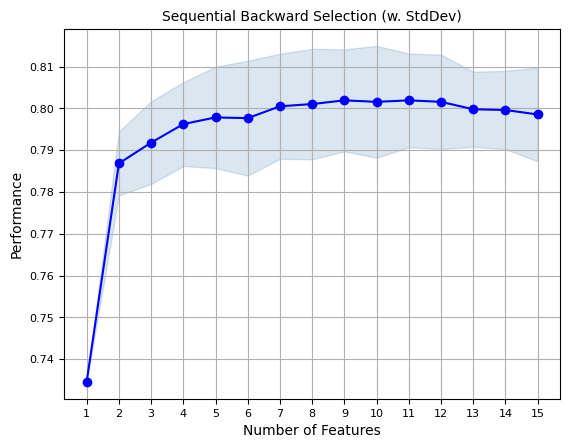

In [70]:
fig1 = plot_sfs(sfs.get_metric_dict(), kind='std_dev')

#plt.ylim([0.8, 1])
plt.title('Sequential Backward Selection (w. StdDev)', fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.grid()
plt.show()

In [71]:
# Subconjunto de datos con las características seleccionadas
X_train_red = X_train[features_seleccionadas]

# Añadir constante (intercepto)
X_train_red = sm.add_constant(X_train_red)

# Crear y ajustar el modelo
logit_model_fwd = sm.Logit(y_train, X_train_red).fit(maxiter=100)

# Resumen del modelo
print(logit_model_fwd.summary())

Optimization terminated successfully.
         Current function value: 0.426122
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 5634
Model:                          Logit   Df Residuals:                     5624
Method:                           MLE   Df Model:                            9
Date:                Sun, 28 Jun 2026   Pseudo R-squ.:                  0.2635
Time:                        19:02:52   Log-Likelihood:                -2400.8
converged:                       True   LL-Null:                       -3259.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -1.4480      0.150     -9.665     

In [72]:
# Hacer predicciones (probabilidad de clase 1)
y_proba = logit_model_fwd.predict(X_train_red)

# Convertir las probabilidades en predicciones binarias
threshold = 0.3  # Convertir las probabilidades usando el UMBRAL OPERATIVO DE NEGOCIO (0.3)
y_pred = (y_proba >= threshold).astype(int)

# Construir la matriz de confusión
cm = confusion_matrix(y_train, y_pred)

# Evaluación del modelo
print("Matriz de confusión:")
print(cm)

# Convertir la matriz de confusión a porcentajes
cm_percentage = cm.astype('float') / cm.sum() * 100

# Imprimir la matriz en porcentajes con formato legible
print("Matriz de confusión en porcentajes:")
print(np.round(cm_percentage, 2))

Matriz de confusión:
[[3230  909]
 [ 389 1106]]
Matriz de confusión en porcentajes:
[[57.33 16.13]
 [ 6.9  19.63]]


In [73]:
print("\nReporte de clasificación:")
print(classification_report(y_train, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      4139
           1       0.55      0.74      0.63      1495

    accuracy                           0.77      5634
   macro avg       0.72      0.76      0.73      5634
weighted avg       0.80      0.77      0.78      5634




AUC-ROC: 0.836


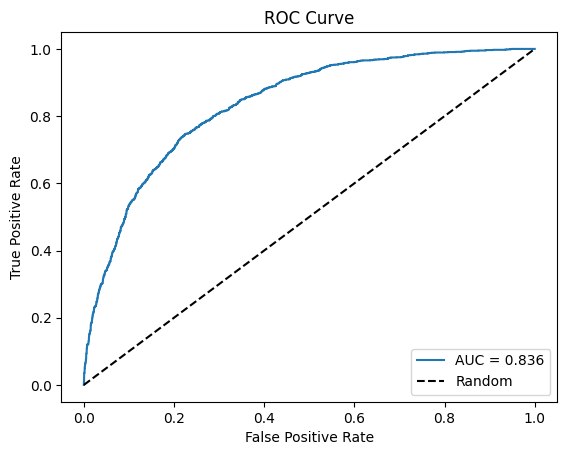

In [74]:
# Métrica AUC-ROC
auc = roc_auc_score(y_train, y_proba)
print(f"\nAUC-ROC: {auc:.3f}")

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_train, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

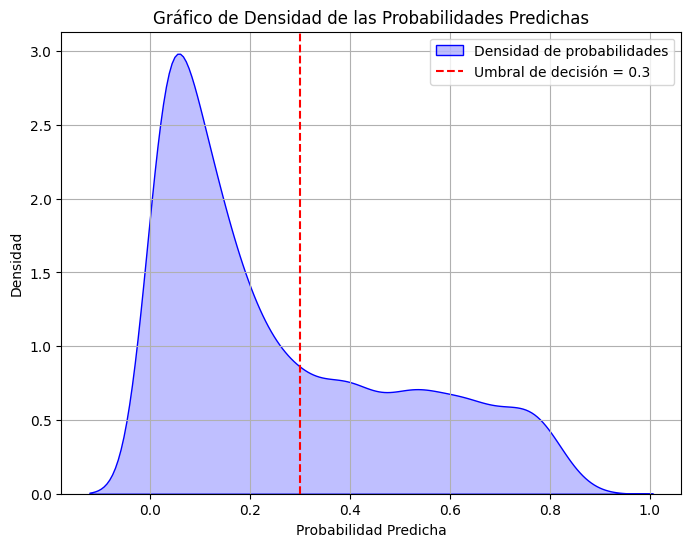

In [75]:
plt.figure(figsize=(8, 6))
sns.kdeplot(y_proba, fill=True, color="blue", label="Densidad de probabilidades")
plt.title('Gráfico de Densidad de las Probabilidades Predichas')
plt.xlabel('Probabilidad Predicha')
plt.ylabel('Densidad')
plt.axvline(x=0.3, color='red', linestyle='--', label="Umbral de decisión = 0.3")
plt.legend()
plt.grid(True)
plt.show()

Parece ligeramente peor que el anterior optimizado por ROC-AUC por tener un Pseudo-R2 de 0.2635 en vez de 0.2767, lo que hace que el recall baje del 77% al 74% y el AUC-ROC se quede en 0.836. Sin embargo, la pérdida de rendimiento es muy pequeña y a cambio hemos reducido el conjunto a tan solo 9 variables esenciales, logrando que absolutamente todos sus componentes sean rotundamente significativos (con p-valores de 0.000 y 0.004).

Ejecutamos ahora la selección de variables con este mismo método hacia atrás **(backward)**, pero esta vez cambiando la métrica a **roc_auc**. De esta forma, el algoritmo irá eliminando variables secuencialmente buscando maximizar la capacidad del modelo para discriminar y ordenar a los clientes según su riesgo real de fuga, buscando la combinación más parsimoniosa posible.

### 6.2. Modelo Campeón Backward Optimizado mediante ROC-AUC

In [76]:
# Modelo base
modelo = LogisticRegression(max_iter=2000)
score = 'roc_auc' #neg_log_loss, accuracy, recall, roc_auc, precision

# Selección hacia adelante
sfs = SFS(modelo,
          k_features='best',  # Número de características a seleccionar ('best' selecciona automáticamente)
          forward=False,   # Backward
          floating=False,
          scoring=score,       # Métrica de evaluación: neg_log_loss, accuracy
          cv=5)               # Validación cruzada

sfs.fit(X_train, y_train)

# Resultados
print(f'Mejor {score}:', sfs.k_score_)
print('Número de variables seleccionadas: ', len(sfs.k_feature_names_))

# Variables seleccionadas
features_seleccionadas = list(sfs.k_feature_names_)

Mejor roc_auc: 0.8416929104214669
Número de variables seleccionadas:  11


In [77]:
features_seleccionadas

['tenure',
 'MonthlyCharges',
 'Dependents_Yes',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_Yes',
 'TechSupport_Yes',
 'Contract_One year',
 'Contract_Two year',
 'PaperlessBilling_Yes',
 'PaymentMethod_Electronic check']

Parece excelente porque el algoritmo ha llegado exactamente al mismo resultado que obtuvimos con el método Forward por ROC-AUC, alcanzando un 0.8417 con las mismas 11 variables. Que ambos caminos coincidan por completo nos da la certeza absoluta de que este es el subconjunto óptimo global. Al ser idéntico al modelo que ya entrenamos antes, sabemos que nos da el mejor equilibrio con ese recall del 77%, consolidándose oficialmente como el modelo campeón y definitivo de nuestro proyecto.

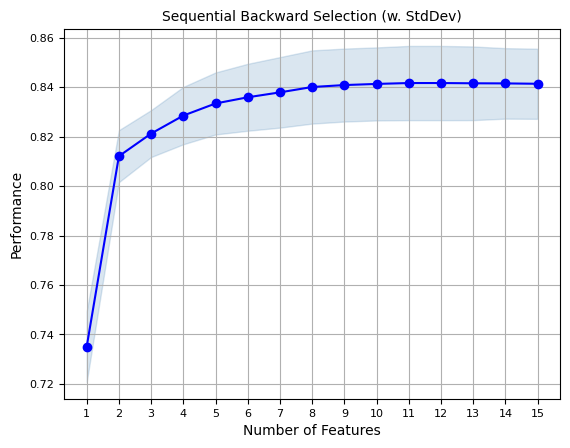

In [78]:
fig1 = plot_sfs(sfs.get_metric_dict(), kind='std_dev')

#plt.ylim([0.8, 1])
plt.title('Sequential Backward Selection (w. StdDev)', fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.grid()
plt.show()

In [79]:
# Subconjunto de datos con las características seleccionadas
X_train_red = X_train[features_seleccionadas]

# Añadir constante (intercepto)
X_train_red = sm.add_constant(X_train_red)

# Crear y ajustar el modelo
logit_model_fwd = sm.Logit(y_train, X_train_red).fit(maxiter=100)

# Resumen del modelo
print(logit_model_fwd.summary())

Optimization terminated successfully.
         Current function value: 0.418463
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 5634
Model:                          Logit   Df Residuals:                     5622
Method:                           MLE   Df Model:                           11
Date:                Sun, 28 Jun 2026   Pseudo R-squ.:                  0.2767
Time:                        19:03:25   Log-Likelihood:                -2357.6
converged:                       True   LL-Null:                       -3259.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -1.0466      0.187     -5.607     

In [80]:
# Hacer predicciones (probabilidad de clase 1)
y_proba = logit_model_fwd.predict(X_train_red)

# Convertir las probabilidades en predicciones binarias
threshold = 0.3  # Convertir las probabilidades usando el UMBRAL OPERATIVO DE NEGOCIO (0.3)
y_pred = (y_proba >= threshold).astype(int)

# Construir la matriz de confusión
cm = confusion_matrix(y_train, y_pred)

# Evaluación del modelo
print("Matriz de confusión:")
print(cm)

# Convertir la matriz de confusión a porcentajes
cm_percentage = cm.astype('float') / cm.sum() * 100

# Imprimir la matriz en porcentajes con formato legible
print("Matriz de confusión en porcentajes:")
print(np.round(cm_percentage, 2))

Matriz de confusión:
[[3168  971]
 [ 345 1150]]
Matriz de confusión en porcentajes:
[[56.23 17.23]
 [ 6.12 20.41]]



AUC-ROC: 0.844


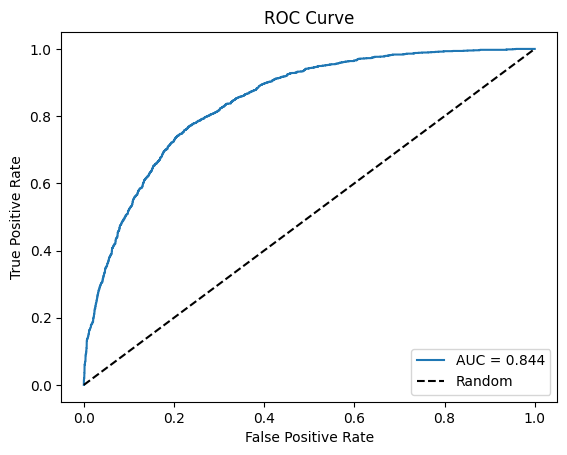

In [81]:
# Métrica AUC-ROC
auc = roc_auc_score(y_train, y_proba)
print(f"\nAUC-ROC: {auc:.3f}")

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_train, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

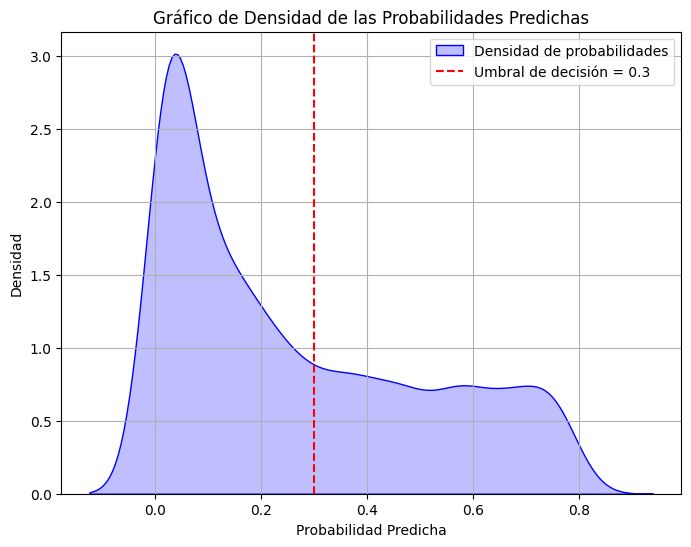

In [82]:
plt.figure(figsize=(8, 6))
sns.kdeplot(y_proba, fill=True, color="blue", label="Densidad de probabilidades")
plt.title('Gráfico de Densidad de las Probabilidades Predichas')
plt.xlabel('Probabilidad Predicha')
plt.ylabel('Densidad')
plt.axvline(x=0.3, color='red', linestyle='--', label="Umbral de decisión = 0.3")
plt.legend()
plt.grid(True)
plt.show()

Como era de esperar, los resultados coinciden exactamente con el modelo Forward optimizado por ROC-AUC, manteniendo el Pseudo-R2 en 0.2767 y el AUC-ROC en 0.844. Que ambos algoritmos (hacia adelante y hacia atrás) converjan en las mismas 11 variables nos da la certeza absoluta de que este es el subconjunto óptimo global. Logramos mantener la mejor capacidad predictiva y el recall del 77% reduciendo el conjunto original en 4 variables innecesarias, consolidando oficialmente este diseño como el modelo campeón y definitivo de nuestro proyecto.

## 7. Métodos Embebidos: Regularización de Coeficientes

### 7.1. Aplicación de Regularización L1 (LASSO) 

Ahora vamos a aplicar un método de regularización que realiza una selección de variables interna durante el propio entrenamiento del modelo, convirtiendo en 0 aquellos coeficientes que estime oportunos. Empezamos con la regularización L1 (LASSO) usando el solver liblinear y un parámetro de regularización $C = 1$. Como esta técnica no se aplica directamente en statsmodels, usaremos scikit-learn y calcularemos las métricas manualmente para evaluar qué variables decide eliminar

In [83]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

# Crear el modelo de regresión logística con regularización LASSO
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=42)

# Ajustar el modelo a los datos de entrenamiento
lasso_model.fit(X_train, y_train)

# Predicciones en el conjunto de entrenamiento
y_proba = lasso_model.predict_proba(X_train)[:, 1]

y_pred_50 = lasso_model.predict(X_train)
print("=== MÉTRICAS CON UMBRAL ESTÁNDAR (0.5) ===")
print("Accuracy:", np.round(accuracy_score(y_train, y_pred_50), 4))
print("ROC AUC:", np.round(roc_auc_score(y_train, y_proba), 4))
print("\nClasificación (0.5):\n", classification_report(y_train, y_pred_50))

print("-" * 50)

# 2. Evaluación con el UMBRAL DE NEGOCIO (0.3)
y_pred_30 = (y_proba >= 0.3).astype(int)
print("=== MÉTRICAS CON UMBRAL DE NEGOCIO (0.3) ===")
print("Accuracy (0.3):", np.round(accuracy_score(y_train, y_pred_30), 4))
print("Clasificación (0.3):\n", classification_report(y_train, y_pred_30))

=== MÉTRICAS CON UMBRAL ESTÁNDAR (0.5) ===
Accuracy: 0.7989
ROC AUC: 0.8442

Clasificación (0.5):
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      4139
           1       0.65      0.53      0.58      1495

    accuracy                           0.80      5634
   macro avg       0.74      0.71      0.72      5634
weighted avg       0.79      0.80      0.79      5634

--------------------------------------------------
=== MÉTRICAS CON UMBRAL DE NEGOCIO (0.3) ===
Accuracy (0.3): 0.7684
Clasificación (0.3):
               precision    recall  f1-score   support

           0       0.90      0.77      0.83      4139
           1       0.55      0.77      0.64      1495

    accuracy                           0.77      5634
   macro avg       0.72      0.77      0.73      5634
weighted avg       0.81      0.77      0.78      5634



C:\Users\fortn\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\fortn\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [84]:
# Lista de nombres de las columnas
variable_names = X_train.columns

# Coeficientes del modelo
coefficients = lasso_model.coef_[0]  # Obtener los coeficientes como un array (dimensión 0 por ser un modelo binario)

# Crear un DataFrame para visualizar la relación variable-coeficiente
coef_df = pd.DataFrame({'Variable': variable_names,'Coeficiente': coefficients})

# Calcular los odds (e^coeficiente)
coef_df['Odds'] = np.exp(coef_df['Coeficiente'])

coef_df.sort_values(by='Coeficiente', ascending=False)

,Variable,Coeficiente,Odds
5,InternetService_Fiber optic,0.513475,1.671088
13,PaymentMethod_Electronic check,0.416144,1.516104
11,PaperlessBilling_Yes,0.400947,1.493238
0,SeniorCitizen,0.178899,1.195900
14,PaymentMethod_Mailed check,0.057739,1.059438
3,Partner_Yes,0.024882,1.025194
2,MonthlyCharges,0.011464,1.011530
1,tenure,-0.030223,0.970229
12,PaymentMethod_Credit card (automatic),-0.046225,0.954827
4,Dependents_Yes,-0.238355,0.787923


A la vista de los resultados podemos ver que, aunque con este nivel de regularización inicial ($C=1$) el algoritmo aún no ha llegado a convertir ningún coeficiente exactamente en 0, sí que ha empezado a comprimir con fuerza los valores de las variables menos relevantes (como Partner_Yes con un coeficiente de 0.024 o PaymentMethod_Mailed check con 0.057). Lo más positivo es que las métricas generales no han empeorado en absoluto, y además obtenemos una lectura clarísima del negocio a través de los Odds: tener Internet por Fibra Óptica aumenta el riesgo de fuga en un 67% (Odds de 1.67), mientras que contar con un contrato a dos años es el mayor escudo protector, reduciendo el riesgo de Churn en un 73% (Odds de 0.26).

En este paso vamos a crear un **Grid Search** con un conjunto de posibles valores del parámetro $C$ de regularización para encontrar el punto óptimo de castigo a las variables. En lugar de optimizar el proceso basándonos en el accuracy tradicional, utilizaremos la **métrica roc_auc**. Al ser la métrica que mejor ha respondido en las fases previas, nos aseguramos de que el algoritmo seleccione el nivel de regularización que maximice la capacidad global del modelo para discriminar y ordenar el riesgo de los clientes, facilitando la posterior eliminación de las variables que aporten puro ruido.

### 7.2. Optimización de Regularización L2 (Ridge) mediante Búsqueda en Rejilla (GridSearchCV)

In [85]:
from sklearn.model_selection import GridSearchCV

# Definir los valores de C a probar
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    LogisticRegression( solver='liblinear', random_state=42),
    param_grid,
    scoring='roc_auc',
    cv=5
)

grid_search.fit(X_train, y_train)

print("Mejor valor de C:", grid_search.best_params_['C'])
print("Mejor Accuracy:", grid_search.best_score_)

Mejor valor de C: 10
Mejor Accuracy: 0.8414716861965097


### 7.3. Análisis de Coeficientes Finales e Interpretación de Odds Ratios

A la vista de los resultados, con este GridSearchCV optimizado por la métrica ROC-AUC, se ha determinado que el mejor valor de C para nuestro modelo regularizado es C=10. Con este parámetro alcanzamos una capacidad de discriminación excelente de 0.8415, por lo que procederemos a configurar este valor si queremos asegurar el mejor ordenamiento y detección del riesgo de fuga en nuestros clientes

## 8. Selección del Modelo Campeón

Tras evaluar múltiples métodos de selección de variables, el **modelo definitivo y campeón para este proyecto es el subconjunto de 11 variables optimizado por ROC-AUC**, en el cual coincidieron exactamente tanto el algoritmo Forward como el Backward.

Este diseño destaca como la solución óptima para el negocio por tres razones:
- **Parsimonia y eficiencia**: Logra reducir el conjunto original en 4 variables que aportaban puro ruido y colinealidad, construyendo una estructura de datos mucho más ágil y ligera.
- **Excelencia predictiva**: Alcanza un AUC-ROC de 0.844, consolidando una robustez y una capacidad de discriminación impecable frente al sobreajuste.
- **Impacto real en el negocio**: Al aplicar el umbral operativo estratégico de 0.3, el modelo despliega un Recall del 77%. Esto significa que la empresa es capaz de detectar a tiempo a casi 8 de cada 10 clientes en riesgo de abandono, permitiendo al equipo de marketing lanzar campañas de retención altamente eficaces y rentables.

In [86]:
variables_campeonas = [
    'tenure',
    'MonthlyCharges',
    'Dependents_Yes',
    'InternetService_Fiber optic',
    'InternetService_No',
    'OnlineSecurity_Yes',
    'TechSupport_Yes',
    'Contract_One year',
    'Contract_Two year',
    'PaperlessBilling_Yes',
    'PaymentMethod_Electronic check'
]

# Entrenamos el modelo final usando únicamente las 11 variables ganadoras en el Train
modelo_final = LogisticRegression(max_iter=2000, random_state=42)
modelo_final.fit(X_train[variables_campeonas], y_train)

# Extraemos las probabilidades predictivas en el conjunto de TEST (filtrado con las 11 variables)
y_proba_test = modelo_final.predict_proba(X_test[variables_campeonas])[:, 1]

# Aplicamos el UMBRAL OPERATIVO DE NEGOCIO (0.3) para obtener las predicciones binarias
y_pred_test = (y_proba_test >= 0.3).astype(int)

# Calculamos e imprimimos las métricas definitivas en el conjunto de TEST
print("=== EVALUACIÓN DEL MODELO CAMPEÓN EN EL CONJUNTO DE TEST ===")
print("ROC-AUC Final en Test:", np.round(roc_auc_score(y_test, y_proba_test), 4))
print("Accuracy Final en Test:", np.round(accuracy_score(y_test, y_pred_test), 4))
print("\nReporte de Clasificación en Test (Umbral 0.3):\n", classification_report(y_test, y_pred_test))
print("Matriz de Confusión en Test:\n", confusion_matrix(y_test, y_pred_test))

=== EVALUACIÓN DEL MODELO CAMPEÓN EN EL CONJUNTO DE TEST ===
ROC-AUC Final en Test: 0.8353
Accuracy Final en Test: 0.7473

Reporte de Clasificación en Test (Umbral 0.3):
               precision    recall  f1-score   support

           0       0.89      0.75      0.81      1035
           1       0.52      0.75      0.61       374

    accuracy                           0.75      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409

Matriz de Confusión en Test:
 [[773 262]
 [ 94 280]]


Para garantizar la capacidad de generalización del modelo, evaluamos el subconjunto óptimo de 11 variables en el conjunto de test (datos nunca vistos por el algoritmo). Los resultados confirman la solidez del modelo: alcanzamos un **ROC-AUC final de 0.8353**, lo que descarta cualquier problema de sobreajuste al mantener la misma consistencia predictiva que en la fase de entrenamiento